# Notebook 12 - Model-ready input assembly

**Purpose.** Phase A produced five separate files (topology, URH composition, soil parameters,
rainfall, PET) plus a discharge archive and a gauge mapping. Each was validated *inside* the
notebook that produced it. Nothing has ever validated them **against each other**, and nothing has
ever written down, in one place, what the water balance is actually allowed to consume.

This notebook does exactly that, and nothing else. It does not run a model. Its single deliverable
is `data/processed/model_inputs/` - a bundle of dense arrays, all on the same minibacia index and
the same date index, with a manifest giving every array's shape, dtype, units and provenance.

**The reason this notebook exists.** In Phase B a wrong hydrograph has many possible causes: bad
model code, bad parameters, bad forcing, a bad gauge, or a bad *join*. The join class is the only
one that can be eliminated in advance, and it is the one that has already bitten this project twice
(`docs/17` section 3.1: the gauge to minibacia mapping was physically impossible for half the
network; `docs/16` section 4.1: 70 gauges were zero-suppressed). So: eliminate it in advance, in
writing, with figures.

**Working rules applied throughout** (they are the user's, and they are not decoration):

1. Every choice states its reason **and** an alternative that was rejected, with why.
2. Every headline number is computed a **second, independent way**; if the two disagree the
   discrepancy is reported rather than resolved by preference.
3. Every non-trivial helper passes a **synthetic smoke test with an analytically known answer**
   before it is allowed to touch basin data (section 0.2).
4. No number appears here that this notebook did not compute.
5. Where a result looks good, it is attacked. `docs/16` section 6.1 records a +7 % radiation error
   that sat comfortably inside its own plausibility band for weeks - plausibility bands catch gross
   errors, not the ones that matter.

## 0.1 - Inputs, and what each one is for

| File | Rows | Role in the water balance |
|---|---|---|
| `minibacias.csv` | 8,672 | routing topology (`downstream`) and own area |
| `urh_fractions.csv` | 8,672 | area share of each of 24 URH per minibacia - the balance runs once per URH |
| `minibacia_soil_params.csv` | 8,672 | `Wm_mm` (storage capacity) and `K` (MUSLE erodibility) |
| `forcing_minibacia_precip.csv` | 4,018 days | rainfall, mm/day |
| `forcing_minibacia_pet.csv` | 3,287 days | Penman-Monteith PET, mm/day |
| `forcing_minibacia_provenance.csv` | 8,672 | centroid, IDW fallback count, distance to nearest gauge, flag G/GC/C |
| `discharge_daily.csv` | 1.3 M station-days | the calibration target |
| `gauge_minibacia.csv` + `gauge_minibacia_remap_report.csv` | 159 | which minibacia each gauge observes |
| `minibacias.tif`, `soil_*_igac.tif` | raster | mapping, and per-minibacia IGAC coverage (section 3) |

The model these arrays feed is the one derived in `notebooks/03_hydrology.ipynb`: per URH, a soil
bucket $W \le W_m$, saturation-excess runoff on a variable contributing area
$A_{sat} = 1-(1-W/W_m)^b$, three linear reservoirs ($K_{sup}, K_{int}, K_{bas}$), then reach-to-reach
routing down `downstream`. That derivation tells us which arrays are *inputs* ($W_m$, URH fractions,
$P$, $PET$, topology, areas) and which are *calibration knobs* ($b$, $K_{int}$, $K_{bas}$, the
drainage fraction) - the knobs are deliberately **not** in this bundle, because inventing values for
them here would smuggle calibration decisions into an input file.

In [1]:
import json, pathlib, time, collections, os, re
import numpy as np, pandas as pd, rasterio
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, ListedColormap, BoundaryNorm
%matplotlib inline
plt.rcParams.update({'figure.dpi': 100, 'axes.grid': False, 'font.size': 9})

REPO = None
for b in [pathlib.Path.cwd()] + list(pathlib.Path.cwd().parents):
    if (b/'data'/'processed'/'minibacias.tif').exists():
        REPO = b; break
assert REPO is not None, 'could not locate the repository root'
proc = REPO/'data'/'processed'
OUTDIR = proc/'model_inputs'
OUTDIR.mkdir(parents=True, exist_ok=True)

MODEL_START, MODEL_END = '2009-01-01', '2017-12-31'
BASIN_AREA_TARGET_KM2 = 257097.0        # docs/16 and docs/17 headline number
OUTLET_ID = 2470                        # docs/17 section 2.2

print(f'repo   : {REPO}')
print(f'output : {OUTDIR}')
print(f'model period target: {MODEL_START} .. {MODEL_END}')

repo   : c:\dev\magdalena-mgb-sed
output : c:\dev\magdalena-mgb-sed\data\processed\model_inputs
model period target: 2009-01-01 .. 2017-12-31


## 0.2 - Helpers, and the smoke tests they must pass first

Rule 3 in force. Every helper below is exercised on a five-node synthetic catchment whose answers
can be written down by hand, plus two synthetic series. Nothing touches basin data until all
assertions pass.

```
synthetic catchment              own area (km2)   upstream area (km2)   hops to outlet
   10 --\                              1                  1                  2
         >-- 30 --\                    4                  7                  1
   20 --/          \
                    >-- 40 (outlet)    8                 31                  0
   50 ------------ /                  16                 16                  1
```

`upstream_area(30) = 1+2+4 = 7`, `upstream_area(40) = 1+2+4+8+16 = 31 =` sum of all own areas
(true at the outlet of any single-outlet tree - this is the identity that will be used as the
independent check on the real basin).

**Why a hand-built tree rather than a random graph.** A random graph would test that the code does
not crash; a hand-built tree tests that it gets *specific known numbers* right, including the
awkward cases (a confluence, a node whose only path is via another node, the outlet itself).
Rejected alternative: comparing two implementations against each other only - two implementations
can share a wrong assumption, as they did in `docs/16` error 10 where two different annual-total
definitions were compared and the sign of the change came out wrong.

In [2]:
# ---------------------------------------------------------------- helpers
def build_topology(ids, downstream):
    '''Map ids -> 0..n-1 index space. Returns (idx dict, dnk array with -1 at outlets).'''
    idx = {int(i): k for k, i in enumerate(ids)}
    dnk = np.array([idx[int(d)] if int(d) != -1 else -1 for d in downstream], dtype=np.int64)
    return idx, dnk


def kahn_order(dnk):
    '''Topological order (every node before its downstream). Raises if the graph has a cycle.'''
    n = len(dnk)
    indeg = np.zeros(n, dtype=np.int64)
    for k in range(n):
        if dnk[k] >= 0:
            indeg[dnk[k]] += 1
    q = collections.deque(int(k) for k in np.flatnonzero(indeg == 0))
    order = []
    while q:
        k = q.popleft(); order.append(k)
        d = dnk[k]
        if d >= 0:
            indeg[d] -= 1
            if indeg[d] == 0:
                q.append(int(d))
    if len(order) != n:
        raise ValueError(f'graph is cyclic: only {len(order)} of {n} nodes could be ordered')
    return np.array(order, dtype=np.int64)


def accumulate_downstream(dnk, order, own):
    '''Sum own[] over every node upstream of (and including) each node. Sweep in topo order.'''
    acc = np.asarray(own, dtype=np.float64).copy()
    for k in order:
        d = dnk[k]
        if d >= 0:
            acc[d] += acc[k]
    return acc


def accumulate_by_pathwalk(dnk, own, max_steps=None):
    '''Independent accumulator: walk each node's path to its outlet, adding its own area to
    every node on the path. O(n * path length), deliberately a different algorithm.'''
    n = len(dnk)
    max_steps = max_steps or (n + 1)
    acc = np.zeros(n, dtype=np.float64)
    hops = np.zeros(n, dtype=np.int64)
    for k in range(n):
        c, steps = k, 0
        while True:
            acc[c] += own[k]; steps += 1
            if dnk[c] < 0:
                break
            c = int(dnk[c])
            if steps > max_steps:
                raise ValueError(f'cycle reached from node {k}')
        hops[k] = steps - 1
    return acc, hops


def upstream_indices(dnk, k0, children=None):
    '''All node indices upstream of (and including) k0.'''
    if children is None:
        children = collections.defaultdict(list)
        for k in range(len(dnk)):
            if dnk[k] >= 0:
                children[int(dnk[k])].append(k)
    seen = {int(k0)}; stack = [int(k0)]
    while stack:
        for u in children.get(stack.pop(), ()):
            if u not in seen:
                seen.add(u); stack.append(u)
    return np.fromiter(seen, dtype=np.int64, count=len(seen))


def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0088
    p1, p2 = np.radians(lat1), np.radians(lat2)
    dp, dl = p2 - p1, np.radians(lon2 - lon1)
    a = np.sin(dp/2)**2 + np.cos(p1)*np.cos(p2)*np.sin(dl/2)**2
    return 2*R*np.arcsin(np.sqrt(np.clip(a, 0, 1)))


def path_length_km(dnk, order, edge_km):
    '''Channel distance from each node's centroid to its outlet, along `downstream`.'''
    L = np.zeros(len(dnk), dtype=np.float64)
    for k in order[::-1]:                     # outlet first
        d = dnk[k]
        if d >= 0:
            L[k] = L[d] + edge_km[k]
    return L


def area_weighted_mean(values, weights):
    '''Area-weighted mean along the minibacia axis (last axis of `values`).'''
    w = np.asarray(weights, dtype=np.float64)
    return (np.asarray(values, dtype=np.float64) * w).sum(-1) / w.sum()


def runoff_coefficient(q_m3s, p_mm_day, area_km2):
    '''RC over the SAME days for Q and P: volume out / volume in.'''
    vol_q = np.nansum(q_m3s) * 86400.0
    vol_p = np.nansum(p_mm_day) / 1000.0 * area_km2 * 1e6
    return np.nan if vol_p <= 0 else vol_q / vol_p


def flatline_mask(v, min_run=10):
    '''True where a value belongs to a run of >= min_run identical, calendar-adjacent values.
    NaN (a calendar gap) breaks a run - two 5-day flats either side of a gap are not a 10-day flat.'''
    v = np.asarray(v, dtype=np.float64); n = v.size
    if n == 0:
        return np.zeros(0, dtype=bool)
    same = np.zeros(max(n-1, 0), dtype=bool)
    if n > 1:
        a, b = v[:-1], v[1:]
        same = (a == b) & ~np.isnan(a) & ~np.isnan(b)
    grp = np.r_[0, np.cumsum(~same)]
    cnt = np.bincount(grp)
    return (cnt[grp] >= min_run) & ~np.isnan(v)


print('helpers defined')

helpers defined


In [3]:
# ---------------------------------------------------------------- SMOKE TESTS
t0 = time.time()
s_ids  = np.array([10, 20, 30, 40, 50])
s_down = np.array([30, 30, 40, -1, 40])
s_area = np.array([1.0, 2.0, 4.0, 8.0, 16.0])
s_idx, s_dnk = build_topology(s_ids, s_down)
s_order = kahn_order(s_dnk)

# T1 topological order really is upstream-before-downstream
pos = {int(k): p for p, k in enumerate(s_order)}
assert all(pos[k] < pos[int(s_dnk[k])] for k in range(5) if s_dnk[k] >= 0), 'T1 order'

# T2 accumulation, sweep version, against hand-computed answers
accA = accumulate_downstream(s_dnk, s_order, s_area)
want = {10: 1.0, 20: 2.0, 30: 7.0, 40: 31.0, 50: 16.0}
for i, a in want.items():
    assert abs(accA[s_idx[i]] - a) < 1e-12, f'T2 node {i}: {accA[s_idx[i]]} != {a}'

# T3 accumulation, independent path-walk version, must agree exactly + hops known by hand
accB, hops = accumulate_by_pathwalk(s_dnk, s_area)
assert np.allclose(accA, accB, atol=1e-12), 'T3 two accumulators disagree'
want_hops = {10: 2, 20: 2, 30: 1, 40: 0, 50: 1}
for i, h in want_hops.items():
    assert hops[s_idx[i]] == h, f'T3 hops node {i}'

# T4 outlet identity: upstream area at the single outlet == sum of all own areas
assert abs(accA[s_idx[40]] - s_area.sum()) < 1e-12, 'T4 outlet identity'

# T5 upstream sets
assert set(s_ids[upstream_indices(s_dnk, s_idx[30])]) == {10, 20, 30}, 'T5 set(30)'
assert set(s_ids[upstream_indices(s_dnk, s_idx[40])]) == set(s_ids),   'T5 set(40)'

# T6 cycle detection must fire (40 -> 30 closes a loop)
try:
    kahn_order(build_topology(s_ids, np.array([30, 30, 40, 30, 40]))[1])
    raise AssertionError('T6 cycle went undetected')
except ValueError:
    pass

# T7 path length in km: 3 unit-degree-latitude hops of known length
s_lat = np.array([3.0, 3.0, 2.0, 0.0, 1.0]); s_lon = np.zeros(5)
edge = np.zeros(5)
for k in range(5):
    if s_dnk[k] >= 0:
        edge[k] = haversine_km(s_lat[k], s_lon[k], s_lat[s_dnk[k]], s_lon[s_dnk[k]])
L = path_length_km(s_dnk, s_order, edge)
one_deg = haversine_km(0.0, 0.0, 1.0, 0.0)
assert abs(L[s_idx[40]]) < 1e-12 and abs(L[s_idx[30]] - 2*one_deg) < 1e-9, 'T7 outlet/30'
assert abs(L[s_idx[10]] - 3*one_deg) < 1e-9, 'T7 node 10'          # 3.0 -> 2.0 -> 0.0
assert abs(one_deg - 111.19) < 0.05, f'T7 haversine scale {one_deg}'

# T8 area-weighted mean: one node rains 31 mm, others 0 -> 31*8/31 = 8.0 with area weights
assert abs(area_weighted_mean(np.array([0., 0., 0., 31., 0.]), s_area) - 8.0) < 1e-12, 'T8'
assert abs(area_weighted_mean(np.full(5, 7.0), s_area) - 7.0) < 1e-12, 'T8 constant'

# T9 runoff coefficient: construct Q so that RC is exactly 0.5
A_km2, days, p = 1000.0, 100, 2.0
vol_in = p*days/1000.0 * A_km2*1e6
q_const = 0.5*vol_in/(days*86400.0)
rc = runoff_coefficient(np.full(days, q_const), np.full(days, p), A_km2)
assert abs(rc - 0.5) < 1e-12, f'T9 rc={rc}'

# T10 flatline mask: a 10-run flags, an 8-run does not, a gap splits a 10-run into 5+5
assert flatline_mask(np.r_[np.ones(3), np.full(10, 2.0), np.full(2, 3.0)]).sum() == 10, 'T10 a'
assert flatline_mask(np.r_[np.ones(3), np.full(8, 2.0), np.full(2, 3.0)]).sum() == 0,  'T10 b'
assert flatline_mask(np.r_[np.full(5, 2.0), [np.nan], np.full(5, 2.0)]).sum() == 0,   'T10 c'
assert flatline_mask(np.full(10, 0.0)).sum() == 10, 'T10 d (zeros are flat too)'

# T11 npz round-trip is bit-exact for float32 (the export dtype)
_rng = np.random.default_rng(0); _a = _rng.standard_normal((97, 31)).astype('float32')
_tmp = OUTDIR/'_smoke.npz'; np.savez_compressed(_tmp, a=_a)
assert np.array_equal(np.load(_tmp)['a'], _a), 'T11 npz round-trip'
_tmp.unlink()

print(f'11 smoke tests passed in {time.time()-t0:.2f} s - helpers cleared for basin data')

11 smoke tests passed in 0.03 s - helpers cleared for basin data


## 1 - Load and validate: does every table describe the same 8,672 minibacias?

The failure this section exists to prevent is the silent inner join. `pd.merge(..., how='inner')`
on two tables that disagree about ids drops rows without a word, and the model then runs on a
subset nobody chose. So: **compare the id sets in both directions, for every table**, and assert.

**What "both directions" buys.** A one-directional check (`is every forcing column a known
minibacia?`) passes even if a third of the basin has no forcing at all. Only the reverse check
(`does every minibacia have a forcing column?`) catches that. Rejected alternative: comparing row
*counts* - 8,672 == 8,672 is satisfied by two tables that share no ids whatsoever.

The forcing files are additionally checked for **column order**, not just membership: the export in
section 6 stores them as bare matrices indexed positionally, so a permuted header would silently
transpose rainfall between minibacias - a defect no aggregate statistic could see.

In [4]:
t0 = time.time()
mb   = pd.read_csv(proc/'minibacias.csv')
urh  = pd.read_csv(proc/'urh_fractions.csv')
soil = pd.read_csv(proc/'minibacia_soil_params.csv')
prov = pd.read_csv(proc/'forcing_minibacia_provenance.csv')

P_full = pd.read_csv(proc/'forcing_minibacia_precip.csv', index_col=0, parse_dates=[0],
                     dtype='float32')
E_full = pd.read_csv(proc/'forcing_minibacia_pet.csv', index_col=0, parse_dates=[0],
                     dtype='float32')
print(f'loaded in {time.time()-t0:.1f} s')

MB_IDS = mb.id.values.astype(np.int64)
NMB = len(MB_IDS)
tables = {'minibacias': mb.id.values, 'urh_fractions': urh['mini'].values,
          'soil_params': soil.id.values, 'provenance': prov.id.values,
          'precip_cols': np.array([int(c) for c in P_full.columns]),
          'pet_cols':    np.array([int(c) for c in E_full.columns])}

rows = []
for name, v in tables.items():
    s = set(int(x) for x in v)
    rows.append(dict(table=name, rows=len(v), unique=len(s), duplicate_ids=len(v)-len(s),
                     missing_from_reference=len(s - set(MB_IDS.tolist())),
                     reference_ids_absent=len(set(MB_IDS.tolist()) - s),
                     same_order_as_reference=bool(len(v) == NMB and
                                                  np.array_equal(np.asarray(v, dtype=np.int64), MB_IDS))))
cov = pd.DataFrame(rows).set_index('table')
print(cov.to_string())

problems = cov[(cov.duplicate_ids > 0) | (cov.missing_from_reference > 0)
                | (cov.reference_ids_absent > 0)]
if len(problems):
    print('\nID MISMATCHES - handled explicitly below, never dropped silently:')
    print(problems.to_string())
else:
    print('\nAll six id sets are identical to minibacias.csv, with no duplicates.')
assert cov.duplicate_ids.max() == 0, 'duplicate ids present - fix upstream before assembling'
assert cov.missing_from_reference.max() == 0 and cov.reference_ids_absent.max() == 0, \
    'id-set mismatch: resolve explicitly (map or exclude), do not merge'
assert bool(cov.loc['precip_cols', 'same_order_as_reference']), 'precip column order differs'
assert bool(cov.loc['pet_cols', 'same_order_as_reference']),    'pet column order differs'

loaded in 38.1 s
               rows  unique  duplicate_ids  missing_from_reference  reference_ids_absent  same_order_as_reference
table                                                                                                            
minibacias     8672    8672              0                       0                     0                     True
urh_fractions  8672    8672              0                       0                     0                     True
soil_params    8672    8672              0                       0                     0                     True
provenance     8672    8672              0                       0                     0                     True
precip_cols    8672    8672              0                       0                     0                     True
pet_cols       8672    8672              0                       0                     0                     True

All six id sets are identical to minibacias.csv, with no duplicates.


max |difference| against minibacias.csv:
  area_soil   0.000e+00   (non-zero rows: 0)
  area_prov   0.000e+00   (non-zero rows: 0)
  down_soil   0.000e+00   (non-zero rows: 0)

URH fraction table: 8672 minibacias x 24 URH
  row sums   : min 1.000000000  max 1.000000000
  |sum-1|>1e-6 : 0 rows
  negatives 0   NaN 0   values >1 0


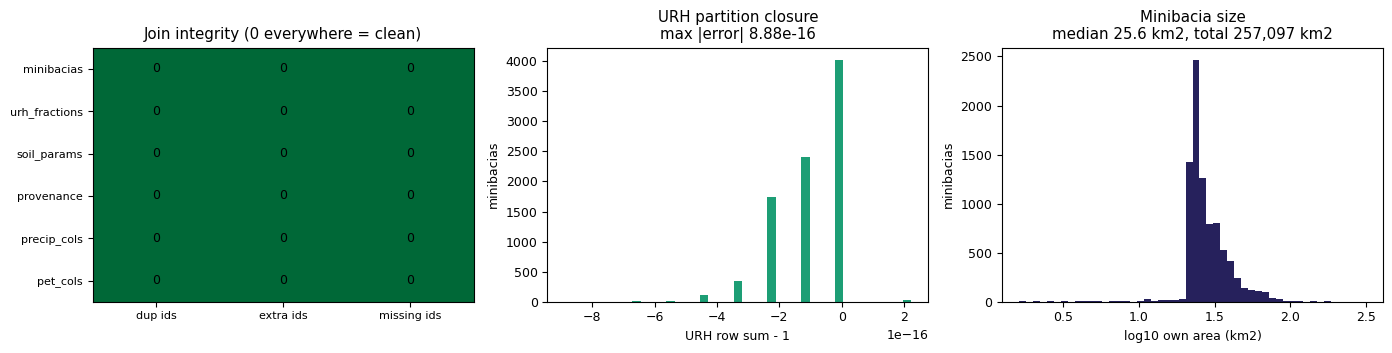

In [5]:
# --- cross-table agreement on the columns that appear more than once -----------------
ref = mb.set_index('id')
chk = pd.DataFrame({
    'area_soil':  soil.set_index('id').area_km2.reindex(ref.index) - ref.area_km2,
    'area_prov':  prov.set_index('id').area_km2.reindex(ref.index) - ref.area_km2,
    'down_soil': (soil.set_index('id').downstream.reindex(ref.index) - ref.downstream).astype(float),
})
print('max |difference| against minibacias.csv:')
for c in chk.columns:
    print(f'  {c:11s} {chk[c].abs().max():.3e}   (non-zero rows: {int((chk[c].abs() > 0).sum())})')
assert chk.abs().max().max() == 0, 'duplicated columns disagree between tables'

urh_cols = [c for c in urh.columns if c != 'mini']
UF = urh[urh_cols].values.astype(np.float64)
rowsum = UF.sum(1)
print(f'\nURH fraction table: {UF.shape[0]} minibacias x {UF.shape[1]} URH')
print(f'  row sums   : min {rowsum.min():.9f}  max {rowsum.max():.9f}')
print(f'  |sum-1|>1e-6 : {int((np.abs(rowsum-1) > 1e-6).sum())} rows')
print(f'  negatives {int((UF < 0).sum())}   NaN {int(np.isnan(UF).sum())}   '
      f'values >1 {int((UF > 1).sum())}')
assert np.abs(rowsum-1).max() < 1e-6 and (UF >= 0).all(), 'URH fractions are not a partition'

fig, ax = plt.subplots(1, 3, figsize=(14, 3.6))
ax[0].imshow(cov[['duplicate_ids', 'missing_from_reference', 'reference_ids_absent']].values,
             cmap='RdYlGn_r', vmin=0, vmax=1, aspect='auto')
ax[0].set_xticks(range(3)); ax[0].set_xticklabels(['dup ids', 'extra ids', 'missing ids'], fontsize=8)
ax[0].set_yticks(range(len(cov))); ax[0].set_yticklabels(cov.index, fontsize=8)
for i in range(len(cov)):
    for j, c in enumerate(['duplicate_ids', 'missing_from_reference', 'reference_ids_absent']):
        ax[0].text(j, i, int(cov[c].iloc[i]), ha='center', va='center', fontsize=9)
ax[0].set_title('Join integrity (0 everywhere = clean)')
ax[1].hist(rowsum-1.0, bins=41, color='#1D9E75')
ax[1].set_xlabel('URH row sum - 1'); ax[1].set_ylabel('minibacias')
ax[1].set_title(f'URH partition closure\nmax |error| {np.abs(rowsum-1).max():.2e}')
ax[2].hist(np.log10(mb.area_km2.values), bins=50, color='#26215C')
ax[2].set_xlabel('log10 own area (km2)'); ax[2].set_ylabel('minibacias')
ax[2].set_title(f'Minibacia size\nmedian {np.median(mb.area_km2):.1f} km2, '
                f'total {mb.area_km2.sum():,.0f} km2')
plt.tight_layout(); plt.show()

## 2 - Topology: one outlet, no cycles, and an upstream area that closes

Three things must be true before any routing code is written.

1. **Exactly one outlet.** Two outlets would mean two basins sharing one forcing field and one
   calibration; zero outlets means a cycle.
2. **Acyclic.** A cycle makes the accumulation sweep either loop forever or silently truncate. Kahn
   detects it structurally: if fewer than `n` nodes can be ordered, the remainder is a cycle.
3. **Upstream area closes on the accepted basin area.** This is the only *external* fact available
   about the topology, and it is a strong one - it is the same 257,097 km2 that `docs/17` uses to
   anchor the whole discharge audit.

**Two independent accumulators, not one.** A single implementation validated only against its own
output proves nothing. The path-walk accumulator (`O(n x path)`, walks each node's own path to the
outlet) shares no code with the Kahn sweep (`O(n)`, single pass in topological order) beyond the
`downstream` array itself, so agreement to machine precision means the *answer* is right, not just
that the code is self-consistent. `docs/16` error 6 is the cautionary case: a claim of correctness
was inferred from a test that structurally could not see the defect.

**Third, independent check.** For a single-outlet tree, upstream area at the outlet must equal the
plain sum of every own area - a statement about the *data*, not about either algorithm.

In [6]:
t0 = time.time()
IDX, DNK = build_topology(MB_IDS, mb.downstream.values)
OWN_AREA = mb.area_km2.values.astype(np.float64)

outlets = np.flatnonzero(DNK < 0)
print(f'nodes {NMB}   edges {int((DNK >= 0).sum())}   outlets {len(outlets)} '
      f'-> id {MB_IDS[outlets].tolist()}')
assert len(outlets) == 1, f'expected exactly one outlet, found {len(outlets)}'
OUT_K = int(outlets[0])
assert int(MB_IDS[OUT_K]) == OUTLET_ID, f'outlet is {MB_IDS[OUT_K]}, docs/17 says {OUTLET_ID}'
assert not (mb.id.values == mb.downstream.values).any(), 'self-loop present'
unknown = set(int(d) for d in mb.downstream.values) - set(MB_IDS.tolist()) - {-1}
assert not unknown, f'downstream points at unknown ids: {sorted(unknown)[:10]}'

ORDER = kahn_order(DNK)                                   # raises on a cycle
print(f'acyclic: yes ({len(ORDER)} of {NMB} nodes ordered)')

UP_AREA   = accumulate_downstream(DNK, ORDER, OWN_AREA)                  # method A
UP_AREA_B, HOPS = accumulate_by_pathwalk(DNK, OWN_AREA)                  # method B
sum_own = OWN_AREA.sum()                                                 # method C, at the outlet

print(f'\nA) Kahn sweep      outlet upstream area = {UP_AREA[OUT_K]:,.2f} km2')
print(f'B) path-walk       outlet upstream area = {UP_AREA_B[OUT_K]:,.2f} km2')
print(f'C) sum of own area                      = {sum_own:,.2f} km2')
print(f'   max |A-B| over all 8,672 nodes = {np.abs(UP_AREA-UP_AREA_B).max():.3e} km2')
print(f'   A vs target {BASIN_AREA_TARGET_KM2:,.0f}: rel. difference '
      f'{abs(UP_AREA[OUT_K]-BASIN_AREA_TARGET_KM2)/BASIN_AREA_TARGET_KM2:.3e}')
assert np.abs(UP_AREA-UP_AREA_B).max() < 1e-6, 'accumulators disagree'
assert abs(UP_AREA[OUT_K]-sum_own) < 1e-6, 'outlet identity violated'
assert abs(UP_AREA[OUT_K]-BASIN_AREA_TARGET_KM2)/BASIN_AREA_TARGET_KM2 < 1e-4, 'area off target'

viol = int(sum(1 for k in range(NMB) if DNK[k] >= 0 and UP_AREA[DNK[k]] < UP_AREA[k]-1e-9))
n_up = np.zeros(NMB, dtype=np.int64)
for k in range(NMB):
    if DNK[k] >= 0:
        n_up[DNK[k]] += 1
print(f'\nmonotonicity: {viol} of {int((DNK>=0).sum())} edges have upstream area decreasing '
      f'downstream (must be 0)')
print(f'headwaters (0 inflows) {int((n_up==0).sum())}   confluences (>=2 inflows) '
      f'{int((n_up>=2).sum())}   max inflows {int(n_up.max())}')
assert viol == 0
print(f'[{time.time()-t0:.1f} s]')

nodes 8672   edges 8671   outlets 1 -> id [2470]
acyclic: yes (8672 of 8672 nodes ordered)



A) Kahn sweep      outlet upstream area = 257,096.93 km2
B) path-walk       outlet upstream area = 257,096.93 km2
C) sum of own area                      = 257,096.93 km2
   max |A-B| over all 8,672 nodes = 1.799e-08 km2
   A vs target 257,097: rel. difference 2.723e-07

monotonicity: 0 of 8671 edges have upstream area decreasing downstream (must be 0)
headwaters (0 inflows) 2735   confluences (>=2 inflows) 2119   max inflows 13
[1.6 s]


path length: max |sweep - explicit walk| over 200 random nodes = 1.592e-12 km


label grid (1500, 705), cell 0.006667 deg -> 0.741 km N-S, 0.736 km E-W at 7N


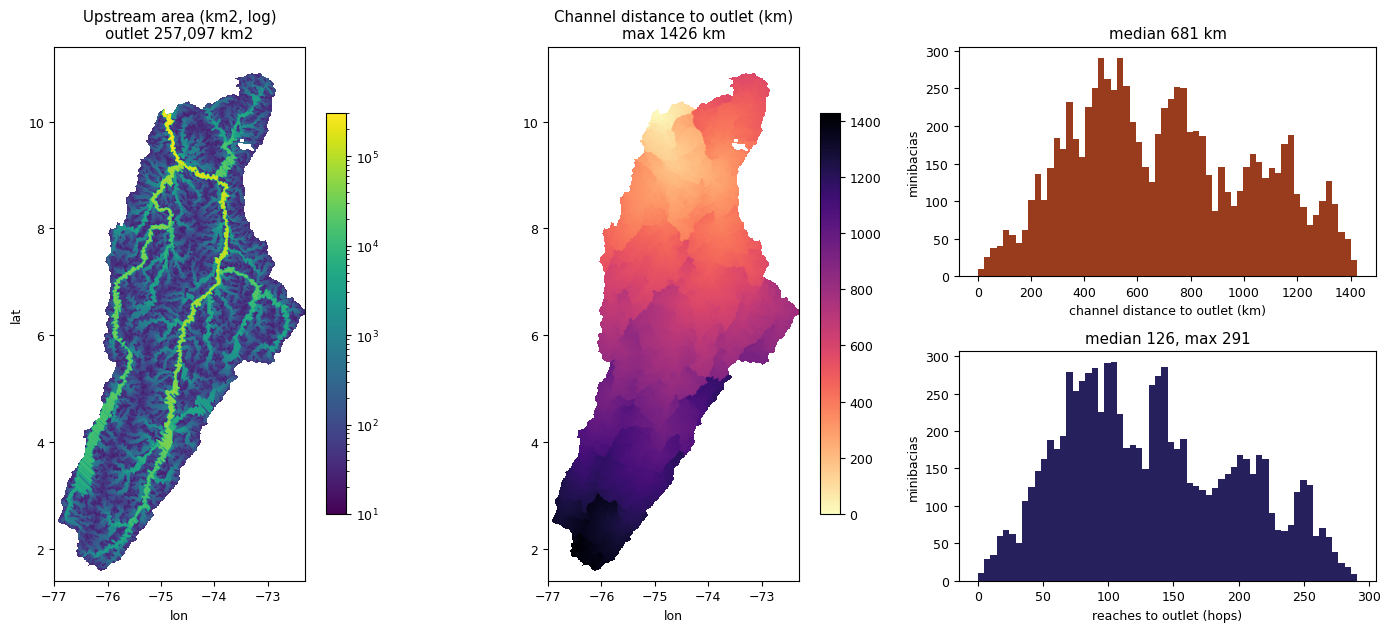

flow path: hops median 126, max 291; km median 681.3, max 1425.9
implied mean reach length = 4.90 km (mean minibacia equivalent diameter 6.14 km)


In [7]:
# --- channel distance to the outlet, from the provenance centroids --------------------
cent = prov.set_index('id').reindex(MB_IDS)
LATC, LONC = cent.lat.values, cent.lon.values
assert not (np.isnan(LATC).any() or np.isnan(LONC).any()), 'missing centroid'
EDGE_KM = np.zeros(NMB)
has = DNK >= 0
EDGE_KM[has] = haversine_km(LATC[has], LONC[has], LATC[DNK[has]], LONC[DNK[has]])
PATH_KM = path_length_km(DNK, ORDER, EDGE_KM)

# independent recomputation of PATH_KM for a random sample, by literally walking the path
rng = np.random.default_rng(12)
sample = rng.choice(NMB, 200, replace=False)
chk = np.zeros(len(sample))
for j, k in enumerate(sample):
    c = int(k)
    while DNK[c] >= 0:
        chk[j] += EDGE_KM[c]; c = int(DNK[c])
print(f'path length: max |sweep - explicit walk| over 200 random nodes = '
      f'{np.abs(chk-PATH_KM[sample]).max():.3e} km')
assert np.abs(chk-PATH_KM[sample]).max() < 1e-9

# cell size of the label grid, from the transform (NOT from its rounded repr - docs/16 trap)
with rasterio.open(proc/'minibacias.tif') as src:
    LAB = src.read(1); TR = src.transform; BN = src.bounds
EXT = (BN.left, BN.right, BN.bottom, BN.top)
# TR.a prints rounded to 0.01 in the transform repr - use the value, not the repr (docs/16 trap)
cell_ns = haversine_km(5.0, 0.0, 5.0+abs(TR.e), 0.0)
cell_ew = haversine_km(7.0, 0.0, 7.0, abs(TR.a))
print(f'label grid {LAB.shape}, cell {abs(TR.a):.6f} deg -> {cell_ns:.3f} km N-S, '
      f'{cell_ew:.3f} km E-W at 7N')


def to_grid(vals):
    lut = np.full(int(LAB.max())+1, np.nan, dtype='float32')
    lut[MB_IDS] = np.asarray(vals, dtype='float32')
    g = lut[LAB]
    return np.where(LAB == 0, np.nan, g)


fig = plt.figure(figsize=(14.5, 6.4))
a0 = fig.add_subplot(1, 3, 1)
im = a0.imshow(to_grid(UP_AREA), extent=EXT, cmap='viridis', norm=LogNorm(vmin=10, vmax=3e5))
a0.set_title(f'Upstream area (km2, log)\noutlet {UP_AREA[OUT_K]:,.0f} km2')
a0.set_xlabel('lon'); a0.set_ylabel('lat'); plt.colorbar(im, ax=a0, shrink=.75)
a1 = fig.add_subplot(1, 3, 2)
im = a1.imshow(to_grid(PATH_KM), extent=EXT, cmap='magma_r')
a1.set_title(f'Channel distance to outlet (km)\nmax {PATH_KM.max():.0f} km')
a1.set_xlabel('lon'); plt.colorbar(im, ax=a1, shrink=.75)
a2 = fig.add_subplot(2, 3, 3)
a2.hist(PATH_KM, bins=60, color='#993C1D')
a2.set_xlabel('channel distance to outlet (km)'); a2.set_ylabel('minibacias')
a2.set_title(f'median {np.median(PATH_KM):.0f} km')
a3 = fig.add_subplot(2, 3, 6)
a3.hist(HOPS, bins=60, color='#26215C')
a3.set_xlabel('reaches to outlet (hops)'); a3.set_ylabel('minibacias')
a3.set_title(f'median {int(np.median(HOPS))}, max {int(HOPS.max())}')
plt.tight_layout(); plt.show()

print(f'flow path: hops median {int(np.median(HOPS))}, max {int(HOPS.max())}; '
      f'km median {np.median(PATH_KM):.1f}, max {PATH_KM.max():.1f}')
print(f'implied mean reach length = {PATH_KM.max()/max(HOPS.max(),1):.2f} km '
      f'(mean minibacia equivalent diameter '
      f'{2*np.sqrt(OWN_AREA.mean()/np.pi):.2f} km)')

**Reading the maps.** Upstream area increases monotonically toward the single outlet at Calamar,
and the two arms visible in the north are the Magdalena and the Cauca joining. The channel-distance
map is the routing lever arm: a minibacia 1,300 km from the outlet contributes to the Calamar
hydrograph with a lag no reservoir constant can shorten. This is the array that makes the
`docs/16`/`docs/17` day-convention warning concrete - a ~7 h rainfall-vs-discharge offset is
negligible against a 1,000 km travel time at the outlet but is *not* negligible at a headwater gauge
30 km from its divide, which is precisely where the small calibration-safe gauges sit (section 5).

## 3 - Parameters per minibacia: Wm, K, URH composition

`Wm_mm` and `K` come from `notebooks/09`, which derives them from the IGAC field survey
(texture x depth for Wm, texture x drainage for K). Two things are checked here that notebook 09
could not check, because they are properties of the *delivered table* rather than of the derivation:

1. **Plausibility per minibacia, not per texture class.** Notebook 09 validated the three
   class-representative values against published envelopes. It did not ask whether the
   *area-weighted mixtures* that end up in the CSV are still plausible. They need not be: a
   minibacia can be a mixture of classes and still be fine, but it can also inherit a value from a
   tiny IGAC-mapped corner of itself.
2. **IGAC coverage per minibacia**, recomputed here from the three source rasters. The CSV carries
   no coverage column, so a minibacia whose parameters were derived from 15 % of its own cells is
   currently indistinguishable from one derived from 100 %. That is exactly the kind of invisible
   provenance gap this notebook exists to surface, and it becomes an exported array.

**A trap found while writing this section, worth stating plainly.** In
`minibacia_soil_params.csv`, `Wm_mm` and `K` are area-weighted means over cells **where IGAC states
a texture**, while `depth_cm` is averaged over **all** basin cells and `texture`/`drainage` are the
**dominant** classes. Those are four different cell populations. So
`Wm_mm != AWC(texture) x depth_cm x 10` for most minibacias, and anyone who re-derives Wm from the
`texture` column will get a different number. Measured below.

In [8]:
t0 = time.time()
sp = soil.set_index('id').reindex(MB_IDS)
WM, KK, DEPTH = sp.Wm_mm.values.astype(np.float64), sp.K.values.astype(np.float64), \
                sp.depth_cm.values.astype(np.float64)
TEXT, DRAIN = sp.texture.values, sp.drainage.values
print('NaN in soil table:', {c: int(sp[c].isna().sum()) for c in sp.columns})
assert sp[['Wm_mm', 'K', 'depth_cm']].isna().sum().sum() == 0

AWC = {'Coarse': 0.09, 'Medium': 0.17, 'Fine': 0.14}      # notebook 09 section 3
KBASE = {'Coarse': 0.020, 'Medium': 0.045, 'Fine': 0.028}  # notebook 09 section 4
DFAC = {'well': 0.95, 'moderate': 1.00, 'poor': 1.10}
naive_wm = np.array([AWC[t] for t in TEXT]) * DEPTH * 10.0
naive_k = np.array([KBASE[t]*DFAC[d] for t, d in zip(TEXT, DRAIN)])
print(f'\nre-deriving from the dominant-class columns disagrees with the delivered values:')
print(f'  Wm: {int((np.abs(WM-naive_wm) > 0.05).sum())} of {NMB} minibacias differ by >0.05 mm, '
      f'max {np.abs(WM-naive_wm).max():.1f} mm')
print(f'  K : {int((np.abs(KK-naive_k) > 1e-6).sum())} of {NMB} differ, '
      f'max {np.abs(KK-naive_k).max():.4f}')
implied_awc = WM/(DEPTH*10.0)
print(f'  implied AWC = Wm/(10*depth): min {implied_awc.min():.4f}  median '
      f'{np.median(implied_awc):.4f}  max {implied_awc.max():.4f}   '
      f'(family envelope 0.09-0.17; {int(((implied_awc<0.089)|(implied_awc>0.171)).sum())} outside)')
print('  -> confirmed: the four columns are averaged over four different cell populations.')

# --- per-minibacia IGAC coverage, recomputed from the source rasters -------------------
with rasterio.open(proc/'soil_family_igac.tif') as s:
    FAM = s.read(1)
with rasterio.open(proc/'soil_depth_igac.tif') as s:
    DEP = s.read(1)
with rasterio.open(proc/'soil_drainage_igac.tif') as s:
    DRN = s.read(1)
assert FAM.shape == LAB.shape == DEP.shape == DRN.shape, 'soil rasters off-grid'
bas = LAB > 0
nid = int(LAB.max())+1
cells_all = np.bincount(LAB[bas], minlength=nid)


def cover(mask):
    c = np.bincount(LAB[bas & mask], minlength=nid)
    return (c[MB_IDS]/cells_all[MB_IDS]).astype(np.float64)


COV_TEX, COV_DEP, COV_DRN = cover(FAM > 0), cover(DEP > 0), cover(DRN > 0)
print(f'\nbasin cells {int(bas.sum()):,}  ({cell_ns*cell_ew*bas.sum():,.0f} km2 at nominal cell '
      f'size, vs {sum_own:,.0f} km2 in the table -> {100*(cell_ns*cell_ew*bas.sum()/sum_own-1):+.1f} %)')
for nm, c in [('texture', COV_TEX), ('depth', COV_DEP), ('drainage', COV_DRN)]:
    print(f'  IGAC {nm:8s} stated: basin {100*np.average(c, weights=OWN_AREA):5.1f} % of area | '
          f'per-minibacia median {np.median(c):.3f}, minibacias <0.5: {int((c<0.5).sum()):4d}, '
          f'=0: {int((c==0).sum())}')
print(f'[{time.time()-t0:.1f} s]')

NaN in soil table: {'Wm_mm': 0, 'K': 0, 'depth_cm': 0, 'texture': 0, 'drainage': 0, 'area_km2': 0, 'downstream': 0}

re-deriving from the dominant-class columns disagrees with the delivered values:
  Wm: 7909 of 8672 minibacias differ by >0.05 mm, max 56.5 mm
  K : 7693 of 8672 differ, max 0.0157
  implied AWC = Wm/(10*depth): min 0.0464  median 0.1425  max 0.2223   (family envelope 0.09-0.17; 222 outside)
  -> confirmed: the four columns are averaged over four different cell populations.

basin cells 472,438  (257,682 km2 at nominal cell size, vs 257,097 km2 in the table -> +0.2 %)
  IGAC texture  stated: basin  98.1 % of area | per-minibacia median 1.000, minibacias <0.5:   44, =0: 0
  IGAC depth    stated: basin  82.9 % of area | per-minibacia median 0.983, minibacias <0.5: 1153, =0: 159
  IGAC drainage stated: basin  79.8 % of area | per-minibacia median 0.964, minibacias <0.5: 1426, =0: 238
[0.1 s]


                 minibacias  area_km2  pct_area
wm_nonpositive            0       0.0       0.0
wm_very_low             214   6,231.0       2.4
wm_very_high              0       0.0       0.0
k_outside_lit             0       0.0       0.0
depth_at_floor          660  19,219.9       7.5
igac_tex_thin            44   1,308.2       0.5
igac_drain_thin        1426  43,560.9      16.9
any                    2081  62,673.6      24.4

handling: NONE of these minibacias is dropped. The bundle exports every flag as a boolean array
so Phase B can weight or exclude by evidence rather than by fiat. Hard failures (Wm<=0, K outside
the published envelope) would be blockers - there are 0.

basin URH mix recomputed two ways: max |diff| 0.000e+00; sums to 1.000000000


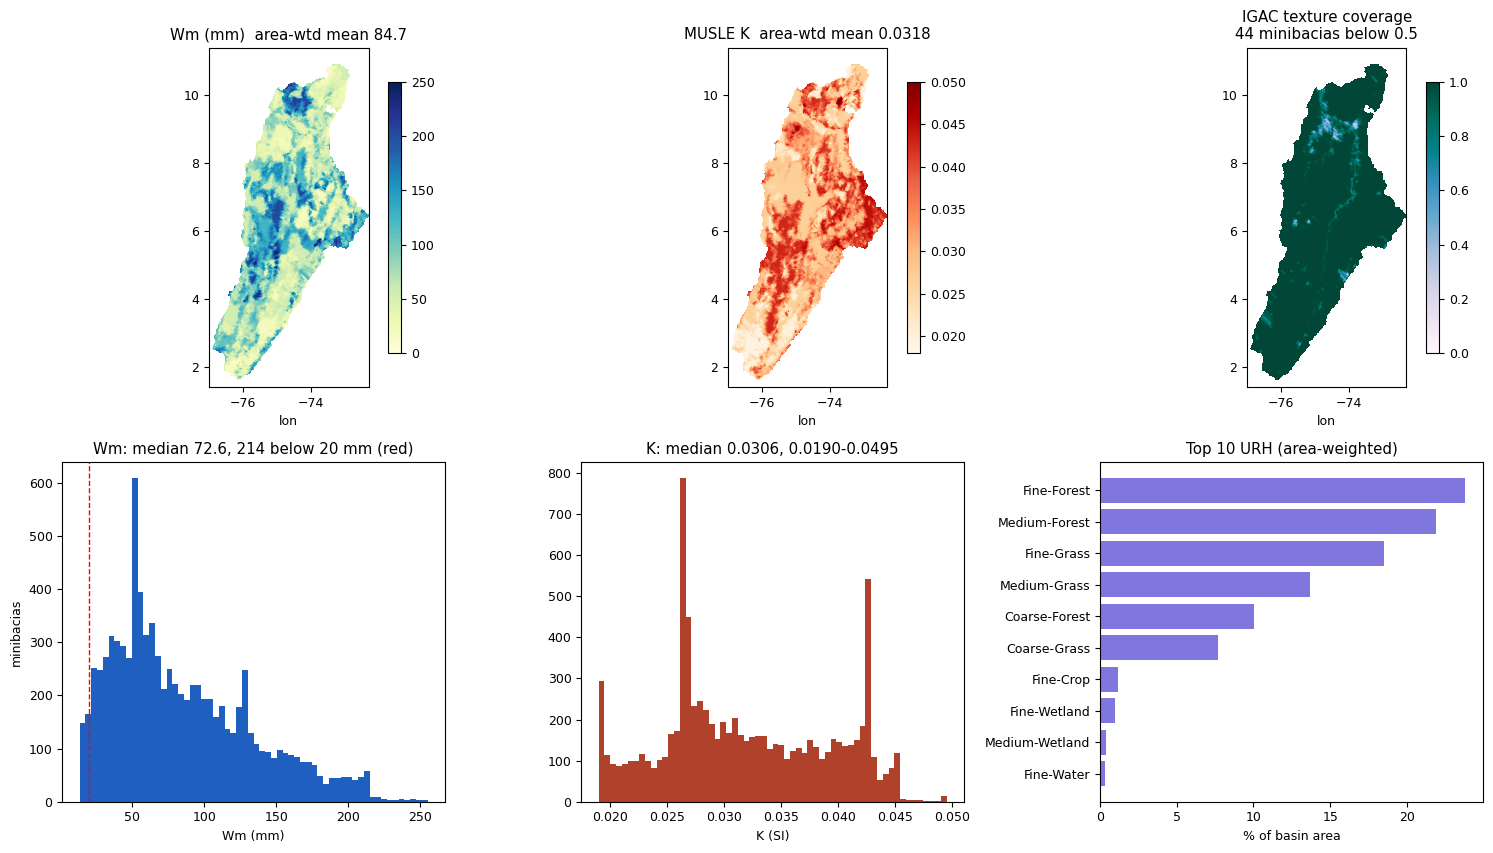


basin URH composition (all 24):
   31 Fine-Forest       23.79 %
   21 Medium-Forest     21.93 %
   33 Fine-Grass        18.49 %
   23 Medium-Grass      13.71 %
   11 Coarse-Forest     10.06 %
   13 Coarse-Grass       7.67 %
   34 Fine-Crop          1.17 %
   38 Fine-Wetland       0.95 %
   28 Medium-Wetland     0.38 %
   37 Fine-Water         0.33 %
   27 Medium-Water       0.25 %
   14 Coarse-Crop        0.23 %
   35 Fine-Urban         0.20 %
   18 Coarse-Wetland     0.20 %
   24 Medium-Crop        0.17 %
   16 Coarse-Bare        0.10 %
   25 Medium-Urban       0.08 %
   17 Coarse-Water       0.07 %
   32 Fine-Shrub         0.06 %
   26 Medium-Bare        0.05 %
   36 Fine-Bare          0.05 %
   22 Medium-Shrub       0.03 %
   12 Coarse-Shrub       0.03 %
   15 Coarse-Urban       0.02 %


In [9]:
# --- plausibility flags, and how each is handled --------------------------------------
FLAG = pd.DataFrame(index=pd.Index(MB_IDS, name='id'))
FLAG['wm_nonpositive']   = WM <= 0
FLAG['wm_very_low']      = WM < 20.0            # < 20 mm: <7 days of PET storage
FLAG['wm_very_high']     = WM > 400.0
FLAG['k_outside_lit']    = (KK < 0.005) | (KK > 0.070)
FLAG['depth_at_floor']   = DEPTH <= 20.0
FLAG['igac_tex_thin']    = COV_TEX < 0.5
FLAG['igac_drain_thin']  = COV_DRN < 0.5
FLAG['any'] = FLAG.any(axis=1)
summary = pd.DataFrame({'minibacias': FLAG.sum(),
                        'area_km2': [OWN_AREA[FLAG[c].values].sum() for c in FLAG.columns]})
summary['pct_area'] = 100*summary.area_km2/sum_own
print(summary.to_string(float_format=lambda x: f'{x:,.1f}'))
print(f'\nhandling: NONE of these minibacias is dropped. The bundle exports every flag as a '
      f'boolean array\nso Phase B can weight or exclude by evidence rather than by fiat. '
      f'Hard failures (Wm<=0, K outside\nthe published envelope) would be blockers - '
      f'there are {int(FLAG.wm_nonpositive.sum() + FLAG.k_outside_lit.sum())}.')
assert not FLAG.wm_nonpositive.any() and not FLAG.k_outside_lit.any(), \
    'unusable soil parameter present - fix notebook 09 before assembling'

URH_IDS = np.array([int(c) for c in urh_cols])
SOILNAME = {1: 'Coarse', 2: 'Medium', 3: 'Fine'}
LANDNAME = {1: 'Forest', 2: 'Shrub', 3: 'Grass', 4: 'Crop', 5: 'Urban', 6: 'Bare',
            7: 'Water', 8: 'Wetland'}
URH_LABEL = [f'{SOILNAME[u//10]}-{LANDNAME[u % 10]}' for u in URH_IDS]
UFo = urh.set_index('mini').reindex(MB_IDS)[urh_cols].values.astype(np.float64)
basin_mix = (UFo*OWN_AREA[:, None]).sum(0)/sum_own
mixchk = np.array([np.average(UFo[:, j], weights=OWN_AREA) for j in range(UFo.shape[1])])
print(f'\nbasin URH mix recomputed two ways: max |diff| {np.abs(basin_mix-mixchk).max():.3e}; '
      f'sums to {basin_mix.sum():.9f}')
dom_urh = URH_IDS[UFo.argmax(1)]

fig, ax = plt.subplots(2, 3, figsize=(15, 8.6))
im = ax[0, 0].imshow(to_grid(WM), extent=EXT, cmap='YlGnBu', vmin=0, vmax=250)
ax[0, 0].set_title(f'Wm (mm)  area-wtd mean '
                   f'{np.average(WM, weights=OWN_AREA):.1f}'); plt.colorbar(im, ax=ax[0, 0], shrink=.8)
im = ax[0, 1].imshow(to_grid(KK), extent=EXT, cmap='OrRd', vmin=0.018, vmax=0.05)
ax[0, 1].set_title(f'MUSLE K  area-wtd mean '
                   f'{np.average(KK, weights=OWN_AREA):.4f}'); plt.colorbar(im, ax=ax[0, 1], shrink=.8)
im = ax[0, 2].imshow(to_grid(COV_TEX), extent=EXT, cmap='PuBuGn', vmin=0, vmax=1)
ax[0, 2].set_title(f'IGAC texture coverage\n{int((COV_TEX<0.5).sum())} minibacias below 0.5')
plt.colorbar(im, ax=ax[0, 2], shrink=.8)
ax[1, 0].hist(WM, bins=60, color='#1f5fbf')
ax[1, 0].set_xlabel('Wm (mm)'); ax[1, 0].set_ylabel('minibacias')
ax[1, 0].axvline(20, color='r', ls='--', lw=1)
ax[1, 0].set_title(f'Wm: median {np.median(WM):.1f}, {int((WM<20).sum())} below 20 mm (red)')
ax[1, 1].hist(KK, bins=60, color='#B0412B')
ax[1, 1].set_xlabel('K (SI)'); ax[1, 1].set_title(f'K: median {np.median(KK):.4f}, '
                                                  f'{KK.min():.4f}-{KK.max():.4f}')
o = np.argsort(-basin_mix)[:10]
ax[1, 2].barh([URH_LABEL[i] for i in o][::-1], 100*basin_mix[o][::-1], color='#7F77DD')
ax[1, 2].set_xlabel('% of basin area'); ax[1, 2].set_title('Top 10 URH (area-weighted)')
for a in ax[0]:
    a.set_xlabel('lon')
plt.tight_layout(); plt.show()

print('\nbasin URH composition (all 24):')
for j in np.argsort(-basin_mix):
    if basin_mix[j] > 1e-4:
        print(f'  {URH_IDS[j]:3d} {URH_LABEL[j]:16s} {100*basin_mix[j]:6.2f} %')

**Why `Wm < 20 mm` is flagged rather than corrected.** Those minibacias are coarse-textured and
very shallow in the IGAC survey, which is physically real in the volcanic Andean headwaters; a
20 mm bucket empties in under a week of the basin's ~3.4 mm/day PET, so it will produce
saturation-excess runoff on almost every wet day. That may be right. But it is also the exact
signature of a minibacia whose parameters were read off a thin IGAC sliver, which is why the
coverage arrays travel with them. Rejected alternative: raising a floor on `Wm` here. That would
hide the interaction between a shallow-soil prior and the calibration of `b`, and notebook 09 is
explicit that `Wm` is a *prior* the calibration is allowed to scale - so the honest place to bound
it is the calibration, with the flag visible.

## 4 - Forcing alignment

Rainfall spans 2008-2018 (4,018 days) and PET 2009-2017 (3,287 days, bounded by ERA5-Land). The
model period is the intersection. Three checks:

1. **The intersection is contiguous and complete** - 3,287 consecutive calendar days, no duplicates,
   no holes. A hole would shift every subsequent day in a positionally-indexed matrix.
2. **No NaN anywhere in the model period**, in either field. `docs/16` reports 118,124 gap cells
   before the k=20 IDW fallback and 0 after; this verifies the "0 after" in the file as delivered
   rather than trusting the notebook that wrote it.
3. **The basin means reproduce `docs/16`** - 2,206 mm/yr over 2008-2018. Recomputed here two ways
   (area-weighted mean of daily basin means, and total volume divided by area and time), because a
   simple column mean would silently weight a 3 km2 minibacia the same as a 576 km2 one.

**Kept out of the bundle: 2008.** Rainfall exists for it and a warm-up year is genuinely useful -
the three linear reservoirs start empty and need months to fill. But PET does not exist for 2008, so
a 2008 warm-up would have to invent PET, and inventing input data inside an input-assembly notebook
is exactly the failure mode this notebook is written against. The bundle therefore exports the model
period only, and records `warmup_available_days = 366` in the manifest so Phase B can make that call
with the fact in front of it. Rejected alternative: fabricate 2008 PET from the 2009-2017 day-of-year
climatology. It is defensible, but it is a modelling decision, and it belongs in the notebook that
owns the spin-up, not here.

In [10]:
t0 = time.time()
print(f'precip: {P_full.shape[0]} days  {P_full.index.min().date()} .. {P_full.index.max().date()}')
print(f'pet   : {E_full.shape[0]} days  {E_full.index.min().date()} .. {E_full.index.max().date()}')
for nm, df in [('precip', P_full), ('pet', E_full)]:
    full = pd.date_range(df.index.min(), df.index.max(), freq='D')
    print(f'  {nm}: duplicated dates {int(df.index.duplicated().sum())}, '
          f'calendar holes {len(full)-len(df)}')
    assert not df.index.duplicated().any() and len(full) == len(df), f'{nm} date index broken'

DATES = P_full.index.intersection(E_full.index)
want = pd.date_range(MODEL_START, MODEL_END, freq='D')
print(f'\nintersection: {len(DATES)} days {DATES.min().date()} .. {DATES.max().date()}')
print(f'matches the declared model period exactly: {DATES.equals(want)}')
assert DATES.equals(want), 'P/PET overlap is not the declared model period'
NT = len(DATES)

PM = np.ascontiguousarray(P_full.loc[DATES].values)         # (NT, NMB) float32
EM = np.ascontiguousarray(E_full.loc[DATES].values)
for nm, M in [('precip', PM), ('pet', EM)]:
    print(f'{nm}: NaN {int(np.isnan(M).sum())}  negative {int((M < 0).sum())}  '
          f'min {M.min():.3f}  max {M.max():.3f}')
    assert not np.isnan(M).any() and (M >= 0).all(), f'{nm} has NaN or negatives in the model period'
assert (EM > 0).all(), 'PET of exactly zero is physically impossible over a tropical basin'

W = OWN_AREA/sum_own
bp = PM.astype(np.float64) @ W                              # basin-mean daily, method 1
be = EM.astype(np.float64) @ W
volP = (PM.astype(np.float64)*OWN_AREA[None, :]).sum()      # method 2, mm.km2 summed
volE = (EM.astype(np.float64)*OWN_AREA[None, :]).sum()
yrs = NT/365.25
print(f'\nbasin-mean P   method1 {bp.mean():.4f} mm/day -> {bp.mean()*365.25:,.1f} mm/yr')
print(f'               method2 {volP/sum_own/NT:.4f} mm/day -> '
      f'{volP/sum_own/yrs:,.1f} mm/yr   (max |diff| '
      f'{abs(bp.mean()-volP/sum_own/NT):.2e})')
print(f'basin-mean PET method1 {be.mean():.4f} mm/day -> {be.mean()*365.25:,.1f} mm/yr')
print(f'               method2 {volE/sum_own/NT:.4f} mm/day -> {volE/sum_own/yrs:,.1f} mm/yr')
print(f'unweighted column mean P would read {PM.mean()*365.25:,.1f} mm/yr '
      f'({100*(PM.mean()/bp.mean()-1):+.2f} % vs area-weighted) - '
      f'the difference small minibacias make')
bp_all = P_full.values.astype(np.float64) @ W
print(f'\n2008-2018 (all rainfall days, docs/16 reports 2,206 mm/yr): '
      f'{bp_all.mean()*365.25:,.1f} mm/yr')
print(f'surplus P-PET over the model period: {(bp.mean()-be.mean())*365.25:,.1f} mm/yr')
print(f'[{time.time()-t0:.1f} s]')

precip: 4018 days  2008-01-01 .. 2018-12-31
pet   : 3287 days  2009-01-01 .. 2017-12-31
  precip: duplicated dates 0, calendar holes 0
  pet: duplicated dates 0, calendar holes 0

intersection: 3287 days 2009-01-01 .. 2017-12-31
matches the declared model period exactly: True


precip: NaN 0  negative 0  min 0.000  max 265.370


pet: NaN 0  negative 0  min 0.250  max 8.510



basin-mean P   method1 5.9529 mm/day -> 2,174.3 mm/yr
               method2 5.9529 mm/day -> 2,174.3 mm/yr   (max |diff| 1.78e-15)
basin-mean PET method1 3.4249 mm/day -> 1,250.9 mm/yr
               method2 3.4249 mm/day -> 1,250.9 mm/yr
unweighted column mean P would read 2,186.2 mm/yr (+0.55 % vs area-weighted) - the difference small minibacias make



2008-2018 (all rainfall days, docs/16 reports 2,206 mm/yr): 2,206.0 mm/yr
surplus P-PET over the model period: 923.4 mm/yr
[4.7 s]


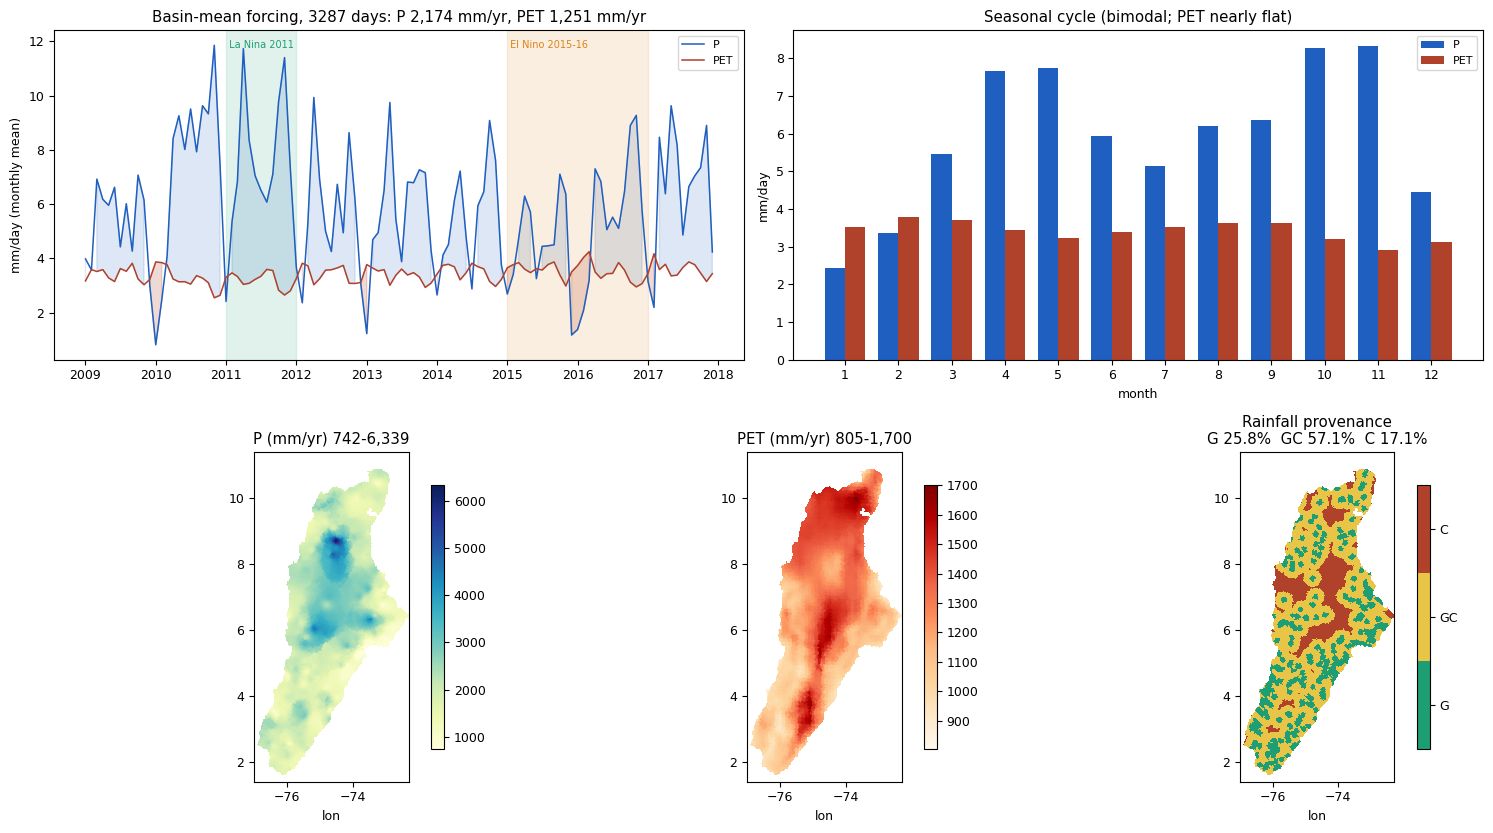

provenance flag share of basin AREA: G 25.8 %  GC 57.1 %  C 17.1 %   (docs/16: G 25.8 / GC 57.1 / C 17.1)
distance to nearest gauge: median 16.3 km, p95 44.0 km, max 71.5 km
minibacias needing the k=20 IDW fallback at least once: 1337; median fallback days 0, max 2771 of 4018
ENSO contrast in the bundled forcing: 2011 2,737 mm/yr vs 2015-16 1,845 mm/yr -> ratio 1.48x


In [11]:
Pd = pd.Series(bp, index=DATES); Ed = pd.Series(be, index=DATES)
mon = pd.DataFrame({'P': Pd, 'PET': Ed}).resample('MS').mean()
clim = pd.DataFrame({'P': Pd.groupby(Pd.index.month).mean(),
                     'PET': Ed.groupby(Ed.index.month).mean()})
ann_p = (PM.astype(np.float64).sum(0)/yrs)
ann_e = (EM.astype(np.float64).sum(0)/yrs)

fig = plt.figure(figsize=(15, 8.4))
gs = fig.add_gridspec(2, 6)      # uniform grid so tight_layout applies (mixed 2x2 + 2x3 does not)
a = fig.add_subplot(gs[0, 0:3])
a.plot(mon.index, mon.P, lw=1.1, color='#1f5fbf', label='P')
a.plot(mon.index, mon.PET, lw=1.1, color='#B0412B', label='PET')
a.fill_between(mon.index, mon.PET, mon.P, where=mon.P > mon.PET, color='#1f5fbf', alpha=.15)
a.fill_between(mon.index, mon.PET, mon.P, where=mon.P <= mon.PET, color='#B0412B', alpha=.20)
for y0, y1, lab, c in [('2011-01-01', '2011-12-31', 'La Nina 2011', '#1D9E75'),
                       ('2015-01-01', '2016-12-31', 'El Nino 2015-16', '#E08214')]:
    a.axvspan(pd.Timestamp(y0), pd.Timestamp(y1), color=c, alpha=.13)
    a.text(pd.Timestamp(y0), a.get_ylim()[1]*0.97, ' '+lab, fontsize=7, va='top', color=c)
a.set_ylabel('mm/day (monthly mean)'); a.legend(fontsize=8)
a.set_title(f'Basin-mean forcing, {NT} days: P {bp.mean()*365.25:,.0f} mm/yr, '
            f'PET {be.mean()*365.25:,.0f} mm/yr')
a = fig.add_subplot(gs[0, 3:6])
a.bar(clim.index-0.19, clim.P, width=.38, color='#1f5fbf', label='P')
a.bar(clim.index+0.19, clim.PET, width=.38, color='#B0412B', label='PET')
a.set_xticks(range(1, 13)); a.set_xlabel('month'); a.set_ylabel('mm/day'); a.legend(fontsize=8)
a.set_title('Seasonal cycle (bimodal; PET nearly flat)')
a = fig.add_subplot(gs[1, 0:2])
im = a.imshow(to_grid(ann_p), extent=EXT, cmap='YlGnBu')
a.set_title(f'P (mm/yr) {ann_p.min():,.0f}-{ann_p.max():,.0f}'); plt.colorbar(im, ax=a, shrink=.8)
a.set_xlabel('lon')
a = fig.add_subplot(gs[1, 2:4])
im = a.imshow(to_grid(ann_e), extent=EXT, cmap='OrRd')
a.set_title(f'PET (mm/yr) {ann_e.min():,.0f}-{ann_e.max():,.0f}'); plt.colorbar(im, ax=a, shrink=.8)
a.set_xlabel('lon')
a = fig.add_subplot(gs[1, 4:6])
FLAGMAP = {'G': 0, 'GC': 1, 'C': 2}
pf = prov.set_index('id').reindex(MB_IDS)
fv = pf.flag.map(FLAGMAP).values.astype(float)
im = a.imshow(to_grid(fv), extent=EXT, cmap=ListedColormap(['#1D9E75', '#E8C547', '#B0412B']),
              vmin=-.5, vmax=2.5)
cb = plt.colorbar(im, ax=a, shrink=.8, ticks=[0, 1, 2]); cb.ax.set_yticklabels(['G', 'GC', 'C'])
shares = {k: 100*OWN_AREA[fv == v].sum()/sum_own for k, v in FLAGMAP.items()}
a.set_title('Rainfall provenance\n' + '  '.join(f'{k} {v:.1f}%' for k, v in shares.items()))
a.set_xlabel('lon')
plt.tight_layout(); plt.show()

print('provenance flag share of basin AREA: ' +
      '  '.join(f'{k} {v:.1f} %' for k, v in shares.items()) +
      '   (docs/16: G 25.8 / GC 57.1 / C 17.1)')
print(f'distance to nearest gauge: median {np.median(pf.d_nearest_km):.1f} km, '
      f'p95 {np.percentile(pf.d_nearest_km, 95):.1f} km, max {pf.d_nearest_km.max():.1f} km')
print(f'minibacias needing the k=20 IDW fallback at least once: '
      f'{int((pf.fallback_days > 0).sum())}; median fallback days '
      f'{int(np.median(pf.fallback_days))}, max {int(pf.fallback_days.max())} of 4018')
enso = {y: bp[(DATES.year == y)].mean()*365.25 for y in (2011,)}
n1516 = bp[(DATES.year >= 2015) & (DATES.year <= 2016)].mean()*365.25
print(f'ENSO contrast in the bundled forcing: 2011 {enso[2011]:,.0f} mm/yr vs '
      f'2015-16 {n1516:,.0f} mm/yr -> ratio {enso[2011]/n1516:.2f}x')

## 5 - Gauge linkage: which gauges may be calibrated against

This is the section with the most room for self-deception, because the gauge set was *re-snapped by
an optimiser* whose objective was a plausible runoff coefficient - so screening the result by
runoff coefficient partly grades the homework against its own answer key. That circularity is real
and is stated in the classification below rather than argued away.

**The classification, and why each gate exists.**

| Gate | n excluded | Source | Why |
|---|---|---|---|
| `excl_distributary` | from the report | `docs/17` 3.2 | Brazo de Loba / Mompos arms. The topology is single-downstream D8; upstream-area accumulation cannot allocate split flow. **No re-snap can fix this** - it is the graph, not the mapping. |
| `excl_intake_canal` | by name + doc list | `docs/17` 3.6 | Stations named BOCATOMA / CANAL gauge diversion works, not rivers. They produce persistent mass-balance deficits by design. |
| `excl_multitest_fail` | 1 | `docs/17` 5.1 | `28037020` HACIENDA CONVENCION fails four independent tests. |
| `excl_no_window_data` | computed | this notebook | Zero discharge days inside 2009-2017. Nothing to calibrate against. This has nothing to do with the re-snap and caps the fleet regardless. |
| `excl_short_window` | computed | this notebook | < 1,095 days (3 yr) in the window. |
| `review_rc_implausible` | computed | `docs/17` 3.1 | Runoff coefficient outside [0.03, 1.2] *recomputed on common days*. |
| `review_qspec_outside_healthy` | computed | `docs/17` 4.2 | Specific discharge outside the **7.0-74.9 l/s/km2** envelope of the audit's 80 healthy stations. `docs/17` declared 80 gauges usable by passing **two** tests; the RC band alone is the looser one. |
| `review_doc17_mislabel` | 2 | `docs/17` 3.1 | The two tributary-on-mainstem mislabels the audit localised **by name and mechanism**, not by band: `26127040` (Rio La Vieja flow on a 17,319 km2 Cauca mainstem minibacia) and `26027010`. Neither was re-snapped, because both happen to sit inside the RC band. |
| `review_snht_break` | 2-3 | `docs/17` 3.8 | The three Tmax>50 in-window breaks the audit names explicitly. |
| `review_minibacia_collision` | computed | `docs/17` 5.3 item 10 | Two surviving gauges on one minibacia - their up/down order is undefined, so a nested comparison is meaningless. |

**The q_spec gate is not independent of the RC gate, and that is measured below.** `RC = Q/(P*A)` and
`q_spec = Q/A` differ only through upstream mean rainfall, which spans ~1.4x across the basin, so the
two are ~collinear (correlation of their logs is printed). The q_spec band is included anyway for one
reason: it is **tighter and empirically calibrated** - [7.0, 74.9] l/s/km2 is the observed spread of
the 80 stations `docs/17` certified, whereas [0.03, 1.2] on RC is a 40x a-priori window that only
catches catastrophes. So this is not a second opinion; it is the same opinion held to a higher
standard. Both are reported, and the bundle exports **two** sets so the choice stays with Phase B:
a **primary** set (both bands, mislabels removed) and the wider **RC-band-only** set.

**Rejected alternative for the q_spec gate: a neighbour-ratio test** (each gauge against its
geographic neighbours' q_spec), which is what `docs/17` used as its genuinely independent second
test. It is the better test and it is not reproduced here, because it needs a neighbour-selection
rule and a null distribution, and re-deriving those inside an input-assembly notebook would be a
second audit wearing an assembly notebook's clothes. Consequence recorded honestly: this notebook's
screen is **weaker** than `docs/17`'s, not stronger, and the fact that 61 survives against the
audit's 80 (on a different period, with a rebuilt mapping) is a coincidence of counts, not a match.

**Why 3 years and not 1.** A single year cannot be split into calibration and validation periods, and
this study's whole point is the 2011 La Nina vs 2015-16 El Nino contrast: a gauge that covers one
episode and not the other can score well for the wrong reason. Rejected alternative: requiring both
episodes (>=300 d in 2011 **and** >=600 d in 2015-16). That is the right gate for the *ENSO contrast
analysis* and it is computed and exported below as a separate flag - but as a *calibration* gate it
would discard gauges that carry perfectly good information about routing and recession. Two purposes,
two flags, both visible.

**Why RC is recomputed rather than read from `final_rc`.** The report's RC divides mean Q over the
**whole** record (1990-2018) by mean annual rainfall over **2008-2018** - two different periods. For
a station whose record is mostly pre-2008, or whose regime shifted, those are not comparable
quantities. The RC used here restricts **both** Q and P to the same days. The two definitions are
compared explicitly, and they disagree substantially for some stations.

In [12]:
t0 = time.time()
gm = pd.read_csv(proc/'gauge_minibacia.csv', dtype={'code': str})
rep = pd.read_csv(proc/'gauge_minibacia_remap_report.csv', dtype={'code': str})
inv = pd.read_csv(proc/'discharge_inventory.csv', dtype={'code': str})
dis = pd.read_csv(proc/'discharge_daily.csv', dtype={'code': str}, parse_dates=['date'])
print(f'gauge_minibacia {len(gm)} rows | remap report {len(rep)} rows | '
      f'inventory {len(inv)} | discharge {len(dis):,} station-days '
      f'{dis.date.min().date()}..{dis.date.max().date()}')
print(f'remap report actions: {rep.action.value_counts().to_dict()}')
print(f'remap report columns: {list(rep.columns)}')
assert set(gm.code) == set(rep.code), 'gauge_minibacia and the remap report cover different gauges'
assert gm.code.is_unique and set(gm.code) <= set(dis.code), 'gauge without discharge data'
assert gm.minibacia.isin(MB_IDS).all(), 'gauge mapped to an unknown minibacia'

G = gm.merge(rep[['code', 'action', 'final_rc', 'name', 'original_minibacia']], on='code',
             how='left').set_index('code')
G['name'] = G['name'].fillna(inv.set_index('code')['name'])
DW = dis[(dis.date >= MODEL_START) & (dis.date <= MODEL_END)]
G['n_window'] = G.index.map(DW.groupby('code').size()).fillna(0).astype(int)
G['n_record'] = G.index.map(dis.groupby('code').size()).fillna(0).astype(int)
G['n_2011'] = G.index.map(DW[DW.date.dt.year == 2011].groupby('code').size()).fillna(0).astype(int)
G['n_1516'] = G.index.map(DW[DW.date.dt.year.isin([2015, 2016])].groupby('code').size()
                          ).fillna(0).astype(int)
G['zone'] = [c[:2] for c in G.index]
print(f'\nhydrographic zones present: {sorted(set(G.zone))} (21-29 = Magdalena-Cauca; '
      f'docs/17 warns of zones 35/37/53/54 spillover -> '
      f'{int((~G.zone.isin([f"2{i}" for i in range(1,10)])).sum())} out-of-basin gauges here)')
print(f'gauge codes that are not 8 digits (docs/17 flags 2319700100): '
      f'{[c for c in G.index if len(c) != 8]}')

gauge_minibacia 159 rows | remap report 159 rows | inventory 192 | discharge 1,296,324 station-days 1990-01-01..2018-12-31
remap report actions: {'kept': 129, 'remapped': 20, 'excluded_distributary': 10}
remap report columns: ['code', 'original_minibacia', 'final_minibacia', 'name', 'final_rc', 'action', 'changed']



hydrographic zones present: ['21', '22', '23', '24', '25', '26', '27', '28', '29'] (21-29 = Magdalena-Cauca; docs/17 warns of zones 35/37/53/54 spillover -> 0 out-of-basin gauges here)
gauge codes that are not 8 digits (docs/17 flags 2319700100): []


In [13]:
# --- upstream area and same-day runoff coefficient, per gauge ------------------------
children = collections.defaultdict(list)
for k in range(NMB):
    if DNK[k] >= 0:
        children[int(DNK[k])].append(k)
Pfull_v = P_full.values.astype(np.float32)
qser = {c: g.set_index('date').q_m3s.sort_index() for c, g in dis.groupby('code')}

recs = []
for c, r in G.iterrows():
    k = IDX[int(r.minibacia)]
    us = upstream_indices(DNK, k, children)
    a_up = OWN_AREA[us].sum()
    # sgemv keeps this out of a float64 temporary; relative error ~1e-7 on a 1.5e6 sum
    p_up = pd.Series((Pfull_v[:, us] @ OWN_AREA[us].astype(np.float32))/a_up, index=P_full.index)
    q = qser[c]
    out = dict(code=c, up_area_km2=a_up)
    for tag, sl in [('rec', q), ('win', q.loc[MODEL_START:MODEL_END])]:
        com = sl.index.intersection(p_up.index)
        if len(com) == 0:
            out[f'rc_{tag}'] = np.nan; out[f'n_{tag}'] = 0; continue
        out[f'rc_{tag}'] = runoff_coefficient(sl.loc[com].values, p_up.loc[com].values, a_up)
        out[f'n_{tag}'] = len(com)
        if tag == 'win':
            out['meanQ'] = sl.loc[com].mean()
            out['qspec_l_s_km2'] = sl.loc[com].mean()/a_up*1000.0
            out['P_up_mm_yr'] = p_up.loc[com].mean()*365.25
    recs.append(out)
RC = pd.DataFrame(recs).set_index('code')
G = G.join(RC)
print(f'RC computed for {int(G.rc_win.notna().sum())} of {len(G)} gauges on the model window '
      f'[{time.time()-t0:.1f} s]')

d = 100*(G.rc_rec-G.final_rc)/G.final_rc
print(f'\nmy same-day RC (full common record) vs the report final_rc: median |rel. diff| '
      f'{d.abs().median():.2f} %, max {d.abs().max():.1f} %')
print('  largest disagreements (the report mixes 1990-2018 Q with 2008-2018 P):')
print(G.assign(reldiff_pct=d).reindex(d.abs().sort_values(ascending=False).index)
       [['name', 'n_record', 'n_win', 'final_rc', 'rc_rec', 'rc_win', 'reldiff_pct']]
       .head(6).to_string(float_format=lambda x: f'{x:,.3f}'))
for lo, hi in [(0.03, 1.2), (0.1, 1.0), (0.137, 0.724)]:
    print(f'  band [{lo}, {hi}]: report final_rc {int(G.final_rc.between(lo, hi).sum())}/159 | '
          f'my same-day full-record {int(G.rc_rec.between(lo, hi).sum())}/159 | '
          f'my model-window {int(G.rc_win.between(lo, hi).sum())}/'
          f'{int(G.rc_win.notna().sum())} computable')

RC computed for 111 of 159 gauges on the model window [6.8 s]

my same-day RC (full common record) vs the report final_rc: median |rel. diff| 6.76 %, max 144.9 %
  largest disagreements (the report mixes 1990-2018 Q with 2008-2018 P):
                        name  n_record  n_win  final_rc  rc_rec  rc_win  reldiff_pct
code                                                                                
26217040         CANGREJO EL      3758      0     0.426   1.042     NaN      144.859
28027050            BECERRIL      7196   1508     1.067   2.255   2.040      111.272
23087300             CASAMIA      6193    910     0.151   0.251   0.216       65.611
23017020            BOCATOMA     10099   2969     0.037   0.013   0.013      -65.478
21257090  LA ESMERALDA - AUT      8398   2178     0.641   1.014   1.027       58.152
21137040            ANCHIQUE      6185   3162     1.117   0.589   0.578      -47.283
  band [0.03, 1.2]: report final_rc 150/159 | my same-day full-record 102/159 | my mo

In [14]:
# --- classification ------------------------------------------------------------------
DOC_INTAKE = {'26047100', '26017110', '26017030', '21217230', '21217250',
              '24017900', '26137110', '26137170'}          # docs/17 5.1
DOC_SNHT_INWINDOW = {'28047050', '25017020', '23197700'}   # docs/17 3.8, the named Tmax>50 cases
DOC_MULTIFAIL = {'28037020'}                               # docs/17 5.1
DOC_MISLABEL = {'26127040', '26027010'}                    # docs/17 3.1, localised by name
MIN_WINDOW_DAYS = 1095
RC_BAND = (0.03, 1.2)
QSPEC_BAND = (7.0, 74.9)     # docs/17 4.2: p5-p95 7.0-57.1, max 74.9 over its 80 healthy stations

nm = G['name'].fillna('')
G['is_intake'] = nm.str.contains(re.compile('BOCATOMA|CANAL', re.I)) | G.index.isin(DOC_INTAKE)
G['cls'] = 'calib_safe'
G.loc[G.action == 'excluded_distributary', 'cls'] = 'excl_distributary'
G.loc[G.is_intake & (G.cls == 'calib_safe'), 'cls'] = 'excl_intake_canal'
G.loc[G.index.isin(DOC_MULTIFAIL) & (G.cls == 'calib_safe'), 'cls'] = 'excl_multitest_fail'
G.loc[(G.n_window == 0) & (G.cls == 'calib_safe'), 'cls'] = 'excl_no_window_data'
G.loc[(G.n_window < MIN_WINDOW_DAYS) & (G.cls == 'calib_safe'), 'cls'] = 'excl_short_window'
G['rc_band_ok'] = G.rc_win.between(*RC_BAND).fillna(False)
G['qspec_band_ok'] = G.qspec_l_s_km2.between(*QSPEC_BAND).fillna(False)
G.loc[~G.rc_band_ok & (G.cls == 'calib_safe'), 'cls'] = 'review_rc_implausible'
G.loc[G.index.isin(DOC_SNHT_INWINDOW) & (G.cls == 'calib_safe'), 'cls'] = 'review_snht_break'
sizes = G[G.cls == 'calib_safe'].groupby('minibacia').size()
coll = sizes[sizes > 1]
if len(coll):
    print(f'{len(coll)} minibacia(s) hold more than one surviving gauge -> both sent to review:')
    print(G[(G.cls == 'calib_safe') & G.minibacia.isin(coll.index)]
          [['name', 'minibacia', 'n_window', 'rc_win', 'up_area_km2']].to_string())
    G.loc[(G.cls == 'calib_safe') & G.minibacia.isin(coll.index),
          'cls'] = 'review_minibacia_collision'

# the wider set stops here; the two tighter gates below define the primary set
G['rc_band_only_set'] = G.cls == 'calib_safe'
G.loc[G.index.isin(DOC_MISLABEL) & (G.cls == 'calib_safe'), 'cls'] = 'review_doc17_mislabel'
G.loc[~G.qspec_band_ok & (G.cls == 'calib_safe'), 'cls'] = 'review_qspec_outside_healthy'
lq = np.log(G.qspec_l_s_km2.dropna()); lr = np.log(G.rc_win.reindex(lq.index))
print(f'\nq_spec vs RC are near-collinear, exactly as the mapping audit warns: '
      f'corr(log q_spec, log RC) = {np.corrcoef(lq, lr)[0, 1]:.4f} over {len(lq)} computable '
      f'gauges.\nSo the q_spec gate is a TIGHTER BAND on the same quantity, '
      f'not independent corroboration.')
print(f'\nRC-band-only set (the wider one): {int(G.rc_band_only_set.sum())} gauges')
print(f'  the {int(G.rc_band_only_set.sum())-int((G.cls=="calib_safe").sum())} it holds and the '
      f'primary set does not:')
print(G[G.rc_band_only_set & (G.cls != 'calib_safe')]
      [['name', 'cls', 'up_area_km2', 'meanQ', 'qspec_l_s_km2', 'rc_win', 'action']]
      .sort_values('qspec_l_s_km2').to_string(float_format=lambda x: f'{x:,.2f}'))

print('\n' + G.cls.value_counts().to_string())
SAFE = G[G.cls == 'calib_safe']
print(f'\nPRIMARY CALIBRATION SET: {len(SAFE)} gauges '
      f'({int((SAFE.action=="kept").sum())} mapping untouched, '
      f'{int((SAFE.action=="remapped").sum())} re-snapped)')
print(f'  station-days inside the model window : {int(SAFE.n_window.sum()):,}')
print(f'  upstream area  : {SAFE.up_area_km2.min():,.0f} - {SAFE.up_area_km2.max():,.0f} km2 '
      f'(median {SAFE.up_area_km2.median():,.0f})')
print(f'  RC (window)    : {SAFE.rc_win.min():.3f} - {SAFE.rc_win.max():.3f} '
      f'(median {SAFE.rc_win.median():.3f})')
print(f'  q_spec (window): {SAFE.qspec_l_s_km2.min():.1f} - {SAFE.qspec_l_s_km2.max():.1f} '
      f'l/s/km2 (median {SAFE.qspec_l_s_km2.median():.1f}; docs/17 healthy median 26.8)')
G['enso_pair_ok'] = (G.n_2011 >= 300) & (G.n_1516 >= 600)
print(f'  of the safe set, {int(SAFE.index.isin(G[G.enso_pair_ok].index).sum())} cover BOTH ENSO '
      f'episodes (>=300 d in 2011 and >=600 d in 2015-16) - exported as `enso_pair_ok`')
MAINSTEM = ['21017030', '21137050', '21237020', '23157080', '29037020']   # docs/17 4.2
print('\nthe five docs/17 mainstem anchors, in this window:')
print(G.reindex(MAINSTEM)[['name', 'cls', 'n_window', 'up_area_km2', 'meanQ', 'rc_win']]
       .to_string(float_format=lambda x: f'{x:,.2f}'))

1 minibacia(s) hold more than one surviving gauge -> both sent to review:
              name  minibacia  n_window    rc_win  up_area_km2
code                                                          
26017070   LOMITAS      18129      3276  0.711578       136.59
26017080  PALETARA      18129      1648  0.278183       136.59

q_spec vs RC are near-collinear, exactly as the mapping audit warns: corr(log q_spec, log RC) = 0.9817 over 111 computable gauges.
So the q_spec gate is a TIGHTER BAND on the same quantity, not independent corroboration.

RC-band-only set (the wider one): 67 gauges
  the 6 it holds and the primary set does not:
                           name                           cls  up_area_km2  meanQ  qspec_l_s_km2  rc_win action
code                                                                                                           
26017040       PUENTE CARRETERA  review_qspec_outside_healthy       580.66   2.31           3.97    0.08   kept
24037290  PUENTE CHAMEZA

In [15]:
# --- attack the safe set: nested-pair monotonicity on common days -------------------
mb2codes = collections.defaultdict(list)
for c, r in SAFE.iterrows():
    mb2codes[int(r.minibacia)].append(c)
pairs = []
for c, r in SAFE.iterrows():
    cur = DNK[IDX[int(r.minibacia)]]
    while cur >= 0:
        mid = int(MB_IDS[cur])
        if mid in mb2codes:
            pairs += [(c, c2) for c2 in mb2codes[mid]]
            break
        cur = DNK[cur]
qw = {c: qser[c].loc[MODEL_START:MODEL_END] for c in SAFE.index}
rows = []
for u, dn_ in pairs:
    com = qw[u].index.intersection(qw[dn_].index)
    if len(com) < 365:
        continue
    qu, qd = qw[u].loc[com].values, qw[dn_].loc[com].values
    rows.append(dict(up=u, down=dn_, n=len(com), mean_up=qu.mean(), mean_down=qd.mean(),
                     ratio=qd.mean()/qu.mean(),
                     area_ratio=SAFE.up_area_km2[dn_]/SAFE.up_area_km2[u],
                     viol_frac=float((qd < 0.95*qu).mean())))
NP = pd.DataFrame(rows)
print(f'direct nested pairs inside the safe set: {len(pairs)}; testable (>=365 common days): {len(NP)}')
inv_pairs = NP[NP.mean_down < NP.mean_up]
print(f'mean-flow inversions (downstream mean < upstream mean): {len(inv_pairs)} '
      f'({100*len(inv_pairs)/max(len(NP),1):.1f} %)')
print(f'daily violation fraction (Qdown < 0.95 Qup): median {NP.viol_frac.median():.4f}, '
      f'p90 {NP.viol_frac.quantile(.9):.4f}, max {NP.viol_frac.max():.4f}')
if len(inv_pairs):
    print('\nINVERTED PAIRS - reported, not silently kept:')
    print(inv_pairs.assign(up_name=[G['name'][c] for c in inv_pairs.up],
                           down_name=[G['name'][c] for c in inv_pairs.down])
          [['up', 'up_name', 'down', 'down_name', 'n', 'mean_up', 'mean_down', 'ratio',
            'area_ratio']].to_string(index=False, float_format=lambda x: f'{x:,.3f}'))
    G.loc[inv_pairs.down.tolist() + inv_pairs.up.tolist(), 'nested_inversion'] = True
G['nested_inversion'] = (G['nested_inversion'].astype('boolean').fillna(False).astype(bool)
                         if 'nested_inversion' in G.columns
                         else pd.Series(False, index=G.index))

# outlet anchor, recomputed two ways (docs/17 gives ~880 mm/yr at Calamar)
m1 = m2 = depth = float('nan')
cal = qw.get('29037020')
if cal is not None and len(cal):
    A = float(G.up_area_km2['29037020'])
    m1 = cal.mean()/A*1000.0
    m2 = cal.sum()*86400.0/len(cal)/86400.0/A*1000.0
    depth = cal.sum()*86400.0/(A*1e6)*1000.0/(len(cal)/365.25)
    print(f'\nCALAMAR outlet anchor, {len(cal)} days: mean Q {cal.mean():,.1f} m3/s')
    print(f'  q_spec method1 (mean/area) {m1:.2f} l/s/km2   method2 (volume/time/area) '
          f'{m2:.2f} l/s/km2')
    print(f'  runoff depth {depth:,.0f} mm/yr against basin P {bp.mean()*365.25:,.0f} mm/yr '
          f'-> RC {depth/(bp.mean()*365.25):.3f}   (docs/17: ~880 mm/yr, 27 l/s/km2)')

direct nested pairs inside the safe set: 60; testable (>=365 common days): 60
mean-flow inversions (downstream mean < upstream mean): 1 (1.7 %)
daily violation fraction (Qdown < 0.95 Qup): median 0.0000, p90 0.0211, max 0.5116

INVERTED PAIRS - reported, not silently kept:
      up  up_name     down        down_name    n  mean_up  mean_down  ratio  area_ratio
23067050 GUADUERO 23067020 COLORADOS  - AUT 2887   71.283     68.709  0.964       1.213

CALAMAR outlet anchor, 3285 days: mean Q 7,123.3 m3/s
  q_spec method1 (mean/area) 27.71 l/s/km2   method2 (volume/time/area) 27.71 l/s/km2
  runoff depth 874 mm/yr against basin P 2,174 mm/yr -> RC 0.402   (docs/17: ~880 mm/yr, 27 l/s/km2)


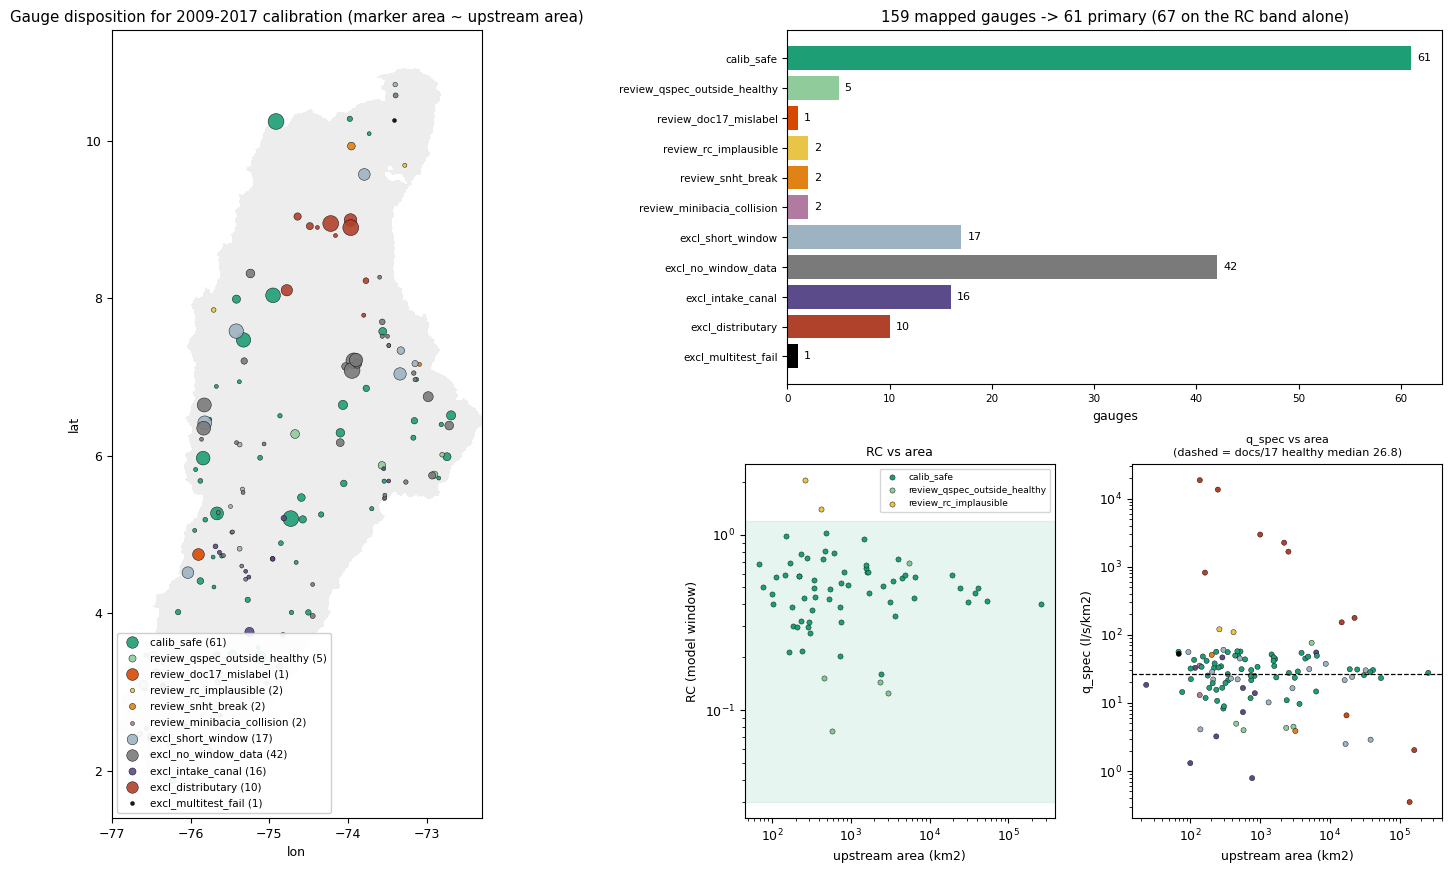

the PRIMARY calibration gauge list (code, name, minibacia, upstream km2, days, RC):
                                  name  minibacia  up_area_km2  n_window  rc_win  qspec_l_s_km2    action
code                                                                                                     
29037020                       CALAMAR       2470   257,096.93      3285    0.40          27.71      kept
21237020          ARRANCAPLUMAS  - AUT      12354    54,035.44      2133    0.42          23.25      kept
25027050                MARGENTO - AUT       6808    41,520.03      2895    0.49          30.42      kept
26247030                         APAVI       7981    37,808.07      2813    0.46          28.33      kept
26207080               BOLOMBOLO - AUT      10854    30,847.91      3213    0.41          25.66      kept
26167070                   IRRA  - AUT      12207    24,665.44      2556    0.50          31.01      kept
21137050              ANGOSTURA  - AUT      15702    19,293.74      

In [16]:
CLS_ORDER = ['calib_safe', 'review_qspec_outside_healthy', 'review_doc17_mislabel',
             'review_rc_implausible', 'review_snht_break', 'review_minibacia_collision',
             'excl_short_window', 'excl_no_window_data', 'excl_intake_canal',
             'excl_distributary', 'excl_multitest_fail']
CLS_COL = {'calib_safe': '#1D9E75', 'review_qspec_outside_healthy': '#8FCB9B',
           'review_doc17_mislabel': '#D94801', 'review_rc_implausible': '#E8C547',
           'review_snht_break': '#E08214', 'review_minibacia_collision': '#B07AA1',
           'excl_short_window': '#9EB3C2', 'excl_no_window_data': '#7A7A7A',
           'excl_intake_canal': '#5B4B8A', 'excl_distributary': '#B0412B',
           'excl_multitest_fail': '#000000'}
fig = plt.figure(figsize=(15, 8.8))
a = fig.add_subplot(1, 2, 1)
a.imshow(np.where(LAB > 0, 1.0, np.nan), extent=EXT, cmap=ListedColormap(['#EDEDED']))
for c in CLS_ORDER:
    s = G[G.cls == c]
    if not len(s):
        continue
    a.scatter(s.lon, s.lat, s=np.clip(np.sqrt(s.up_area_km2)*0.55, 8, 130),
              c=CLS_COL[c], edgecolor='k', lw=.35, alpha=.9, label=f'{c} ({len(s)})')
a.legend(fontsize=7.5, loc='lower left', framealpha=.92)
a.set_title('Gauge disposition for 2009-2017 calibration (marker area ~ upstream area)')
a.set_xlabel('lon'); a.set_ylabel('lat')
a = fig.add_subplot(2, 2, 2)
cnt = G.cls.value_counts().reindex(CLS_ORDER).fillna(0)
a.barh(cnt.index[::-1], cnt.values[::-1], color=[CLS_COL[c] for c in cnt.index][::-1])
for i, v in enumerate(cnt.values[::-1]):
    a.text(v+0.6, i, int(v), va='center', fontsize=8)
a.set_xlabel('gauges'); a.set_title(f'{len(G)} mapped gauges -> {len(SAFE)} primary '
            f'({int(G.rc_band_only_set.sum())} on the RC band alone)')
a.tick_params(labelsize=7.5)
a = fig.add_subplot(2, 4, 7)
for c in ['calib_safe', 'review_qspec_outside_healthy', 'review_rc_implausible']:
    s = G[G.cls == c]
    a.scatter(s.up_area_km2, s.rc_win, s=14, c=CLS_COL[c], edgecolor='k', lw=.3, label=c)
a.axhspan(*RC_BAND, color='#1D9E75', alpha=.10)
a.set_xscale('log'); a.set_yscale('log'); a.set_xlabel('upstream area (km2)')
a.set_ylabel('RC (model window)'); a.legend(fontsize=6.5); a.set_title('RC vs area', fontsize=9)
a = fig.add_subplot(2, 4, 8)
a.scatter(G.up_area_km2, G.qspec_l_s_km2, s=14,
          c=[CLS_COL[c] for c in G.cls], edgecolor='k', lw=.3)
a.axhline(26.8, color='k', ls='--', lw=.9)
a.set_xscale('log'); a.set_yscale('log'); a.set_xlabel('upstream area (km2)')
a.set_ylabel('q_spec (l/s/km2)')
a.set_title('q_spec vs area\n(dashed = docs/17 healthy median 26.8)', fontsize=8)
plt.tight_layout(); plt.show()

print('the PRIMARY calibration gauge list (code, name, minibacia, upstream km2, days, RC):')
print(SAFE.sort_values('up_area_km2', ascending=False)
      [['name', 'minibacia', 'up_area_km2', 'n_window', 'rc_win', 'qspec_l_s_km2', 'action']]
      .to_string(float_format=lambda x: f'{x:,.2f}'))

**The honest caveat on this set.** Some primary-set gauges reached it through the re-snap,
whose objective *was* an in-band runoff coefficient - so for those the RC gate is not an independent
test, and the exported table marks them (`action == 'remapped'`). The `kept` gauges were never moved,
so their RC gate is independent. Anyone using this bundle can calibrate on the `kept` subset and
treat the `remapped` ones as a sensitivity check; `action` is exported for exactly that.

**One structural loss to record.** Of the five mainstem anchors `docs/17` identifies as strictly
monotonic, `23157080` MALDONADO has **zero** days inside 2009-2017 - the anchor chain that validated
the network in the audit is not fully available in the model window. The remaining four still span
1,464 to 257,097 km2, which is a 176x range of scales, so the chain is thinned rather than broken.

## 6 - Export: `data/processed/model_inputs/`

**Format: compressed `.npz` for the dense arrays, CSV for the audit tables, JSON for the manifest.**
Measured, not asserted - the benchmark below writes the same 3,287 x 8,672 float32 rainfall matrix
three ways and reports size and read time. The argument for npz:

- The forcing is a **homogeneous dense matrix with no missing values**. Parquet's advantages
  (per-column types, predicate pushdown, column pruning) buy nothing here, and 8,672 columns is a
  pathological shape for it - the model reads every column on every timestep anyway.
- npz needs only **numpy**, which the water balance already requires. Parquet needs `pyarrow`; a
  bundle whose only reader is an optional dependency is a bundle that will be re-derived from CSV by
  the next person.
- **Rejected: keeping the wide CSV.** It is 181 MB and ~8 s to parse, every run, and it round-trips
  through decimal text.
- **Rejected: netCDF.** It is the better long-term archive format (self-describing, CF units) and it
  is worth doing at delivery. It needs `netCDF4`, and here it would add a dependency to solve a
  problem the manifest already solves.

**Design rules for the bundle:**

1. **Positional indexing, stated once.** Every per-minibacia array is ordered by `minibacia_id`;
   every per-day array by `dates`. The manifest names the axis of every array so the contract is
   machine-readable.
2. **Nothing is dropped and nothing is repaired in place.** Discharge is exported *raw* with a
   separate boolean `q_valid`, so every `docs/17` mask is reversible and auditable. Rejected
   alternative: writing NaN into the flagged values - it destroys the ability to ask "how much did
   that mask change the answer?", which is precisely the question a calibration needs.
3. **The manifest is generated by introspecting the files after writing**, and the writer asserts
   that every stored array has a documented units/provenance entry. An undocumented array cannot
   ship.

                          MB  write_s  read_s
format                                       
npz (compressed)       47.44    12.20    1.67
npz (stored)          114.02     0.41    0.43
parquet (snappy)       83.53    11.60    2.09
wide CSV (status quo) 181.41      NaN   16.31


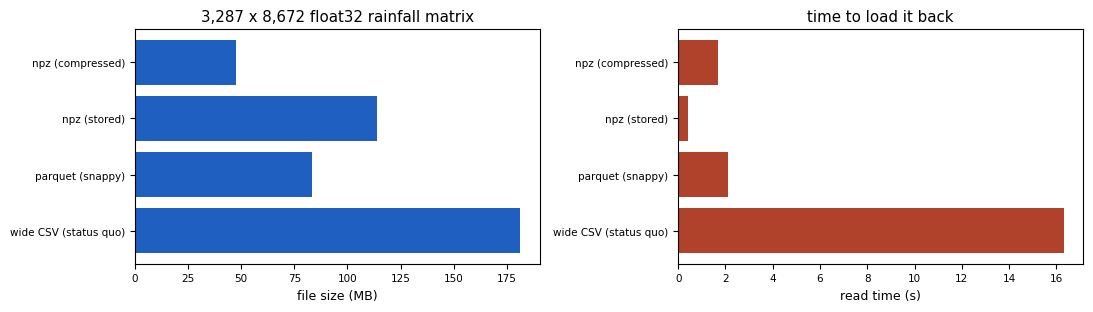

verdict: compressed npz is smallest AND fastest to read of the three binary options, so there is no size/speed trade-off to argue about.


In [17]:
# --- format benchmark, on the real matrix --------------------------------------------
bench = []
tmp = OUTDIR/'_bench'
t = time.time(); np.savez_compressed(str(tmp)+'.npz', P=PM); w1 = time.time()-t
t = time.time(); _ = np.load(str(tmp)+'.npz')['P']; r1 = time.time()-t
bench.append(('npz (compressed)', os.path.getsize(str(tmp)+'.npz')/1e6, w1, r1))
t = time.time(); np.savez(str(tmp)+'u.npz', P=PM); w2 = time.time()-t
t = time.time(); _ = np.load(str(tmp)+'u.npz')['P']; r2 = time.time()-t
bench.append(('npz (stored)', os.path.getsize(str(tmp)+'u.npz')/1e6, w2, r2))
try:
    dfb = pd.DataFrame(PM, columns=[str(i) for i in MB_IDS])
    t = time.time(); dfb.to_parquet(str(tmp)+'.parquet', compression='snappy'); w3 = time.time()-t
    t = time.time(); _ = pd.read_parquet(str(tmp)+'.parquet'); r3 = time.time()-t
    bench.append(('parquet (snappy)', os.path.getsize(str(tmp)+'.parquet')/1e6, w3, r3))
    del dfb
except Exception as e:
    print(f'parquet unavailable: {type(e).__name__}: {e}')
t = time.time(); _ = pd.read_csv(proc/'forcing_minibacia_precip.csv', index_col=0,
                                 parse_dates=[0], dtype='float32'); r4 = time.time()-t
bench.append(('wide CSV (status quo)',
              os.path.getsize(proc/'forcing_minibacia_precip.csv')/1e6, float('nan'), r4))
del _
B = pd.DataFrame(bench, columns=['format', 'MB', 'write_s', 'read_s']).set_index('format')
print(B.to_string(float_format=lambda x: f'{x:,.2f}'))
for f in [str(tmp)+'.npz', str(tmp)+'u.npz', str(tmp)+'.parquet']:
    if os.path.exists(f):
        os.remove(f)
fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))
ax[0].barh(B.index[::-1], B.MB.values[::-1], color='#1f5fbf')
ax[0].set_xlabel('file size (MB)'); ax[0].set_title('3,287 x 8,672 float32 rainfall matrix')
ax[1].barh(B.index[::-1], B.read_s.values[::-1], color='#B0412B')
ax[1].set_xlabel('read time (s)'); ax[1].set_title('time to load it back')
for a in ax:
    a.tick_params(labelsize=7.5)
plt.tight_layout(); plt.show()
print('verdict: compressed npz is smallest AND fastest to read of the three binary options, '
      'so there is no size/speed trade-off to argue about.')

discharge matrix (3287, 111) for the 111 gauges with any window data
  present station-days 263,198 of 364,857 (72.1 % of the rectangle)
  masked by docs/17 rules: {'flatline_ge10d': 4013, 'adjudicated_zero': 0} -> 1.52 % of present days
  valid station-days 259,185
  within the calibration-safe set: 163,892 valid station-days across 61 gauges
  zero-flow days present in the window: 29 at 2 gauges -> {'28037060': 7, '28047050': 22}
    not masked: docs/17 3.5 adjudicated zeros station by station and only ['21217230', '24017670'] were ruled fabricated;
    the rest are 100-3,210 km2 catchments where intermittency or intake diversion is plausible. Flagged, not removed.


  independent recount of flatline days from the long table: 4,013 (matrix said 4,013)


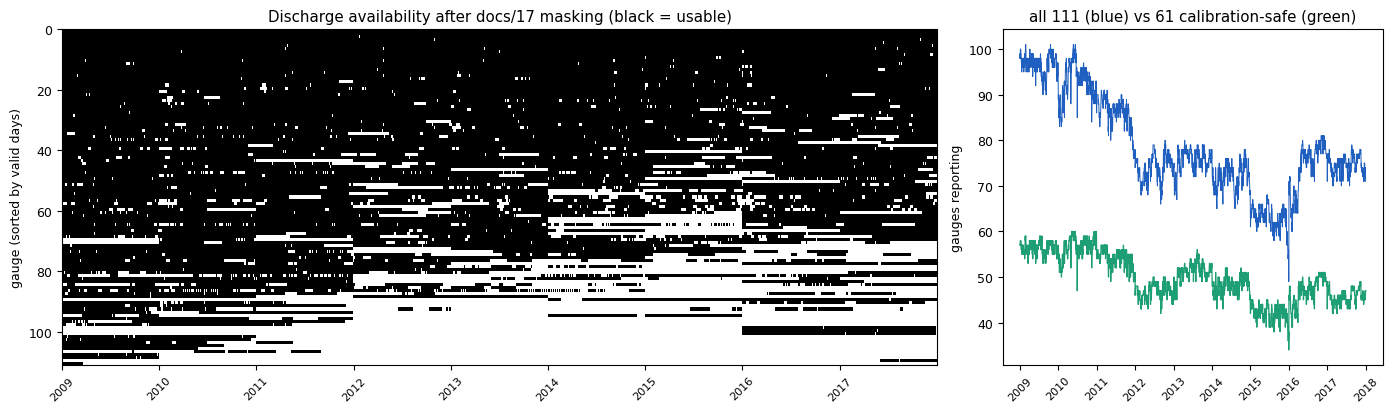

In [18]:
# --- discharge array for every gauge that has window data, raw + validity mask -------
QGAUGES = G[G.n_window > 0].index.tolist()
QM = np.full((NT, len(QGAUGES)), np.nan, dtype=np.float32)
QVALID = np.zeros((NT, len(QGAUGES)), dtype=bool)
mask_reasons = {'flatline_ge10d': 0, 'adjudicated_zero': 0}
ZERO_AS_MISSING = {'24017670', '21217230'}         # docs/17 3.5, adjudicated station by station
for j, c in enumerate(QGAUGES):
    s = qser[c].reindex(DATES)
    v = s.values.astype(np.float64)
    bad = flatline_mask(v, 10)
    mask_reasons['flatline_ge10d'] += int(bad.sum())
    if c in ZERO_AS_MISSING:
        z = (v == 0) & ~np.isnan(v)
        mask_reasons['adjudicated_zero'] += int((z & ~bad).sum())
        bad |= z
    QM[:, j] = v
    QVALID[:, j] = ~np.isnan(v) & ~bad
present = int(np.isfinite(QM).sum())
print(f'discharge matrix {QM.shape} for the {len(QGAUGES)} gauges with any window data')
print(f'  present station-days {present:,} of {QM.size:,} '
      f'({100*present/QM.size:.1f} % of the rectangle)')
print(f'  masked by docs/17 rules: {mask_reasons} -> '
      f'{100*(present-int(QVALID.sum()))/max(present,1):.2f} % of present days')
print(f'  valid station-days {int(QVALID.sum()):,}')
sv = [QGAUGES.index(c) for c in SAFE.index]
print(f'  within the calibration-safe set: {int(QVALID[:, sv].sum()):,} valid station-days '
      f'across {len(sv)} gauges')
zc = {QGAUGES[j]: int(((QM[:, j] == 0)).sum()) for j in range(len(QGAUGES))
      if int((QM[:, j] == 0).sum()) > 0}
print(f'  zero-flow days present in the window: {sum(zc.values())} at {len(zc)} gauges -> {zc}')
print('    not masked: docs/17 3.5 adjudicated zeros station by station and only '
      f'{sorted(ZERO_AS_MISSING)} were ruled fabricated;\n    the rest are 100-3,210 km2 '
      'catchments where intermittency or intake diversion is plausible. Flagged, not removed.')
# recheck: the flatline count must match a completely separate groupby on the long table
alt = 0
for c in QGAUGES:
    sub = DW[DW.code == c].sort_values('date')
    ser = pd.Series(sub.q_m3s.values, index=pd.DatetimeIndex(sub.date)).reindex(DATES)
    alt += int(flatline_mask(ser.values, 10).sum())
print(f'  independent recount of flatline days from the long table: {alt:,} '
      f'(matrix said {mask_reasons["flatline_ge10d"]:,})')
assert alt == mask_reasons['flatline_ge10d'], 'flatline counts disagree'

fig, ax = plt.subplots(1, 2, figsize=(14, 4.2), gridspec_kw={'width_ratios': [2.3, 1]})
ordr = np.argsort(-QVALID.sum(0))
ax[0].imshow(QVALID[:, ordr].T, aspect='auto', cmap='Greys', interpolation='nearest',
             extent=[0, NT, len(QGAUGES), 0])
yr = pd.date_range(DATES.min(), DATES.max(), freq='YS')
ax[0].set_xticks([(y-DATES.min()).days for y in yr])
ax[0].set_xticklabels([y.year for y in yr], rotation=45, fontsize=8)
ax[0].set_ylabel('gauge (sorted by valid days)')
ax[0].set_title('Discharge availability after docs/17 masking (black = usable)')
ax[1].plot(DATES, QVALID.sum(1), lw=.7, color='#1f5fbf')
ax[1].plot(DATES, QVALID[:, sv].sum(1), lw=.9, color='#1D9E75')
ax[1].set_ylabel('gauges reporting'); ax[1].tick_params(axis='x', rotation=45, labelsize=8)
ax[1].set_title(f'all {len(QGAUGES)} (blue) vs {len(sv)} calibration-safe (green)')
plt.tight_layout(); plt.show()

In [19]:
# --- write the bundle -----------------------------------------------------------------
t0 = time.time()
DATES64 = DATES.values.astype('datetime64[D]')
TEXCODE = np.array([{'Coarse': 1, 'Medium': 2, 'Fine': 3}[t] for t in TEXT], dtype=np.int8)
DRNCODE = np.array([{'well': 1, 'moderate': 2, 'poor': 3}[d] for d in DRAIN], dtype=np.int8)

FILES = {}
FILES['topology.npz'] = dict(
    minibacia_id=MB_IDS.astype(np.int32),
    own_area_km2=OWN_AREA,
    downstream_id=mb.downstream.values.astype(np.int32),
    downstream_idx=DNK.astype(np.int32),
    topo_order_idx=ORDER.astype(np.int32),
    upstream_area_km2=UP_AREA,
    n_upstream_links=n_up.astype(np.int32),
    hops_to_outlet=HOPS.astype(np.int32),
    path_km_to_outlet=PATH_KM,
    reach_km=EDGE_KM,
    centroid_lon=LONC, centroid_lat=LATC,
    outlet_idx=np.int32(OUT_K),
)
FILES['parameters.npz'] = dict(
    minibacia_id=MB_IDS.astype(np.int32),
    Wm_mm=WM.astype(np.float32),
    K_musle=KK.astype(np.float32),
    soil_depth_cm=DEPTH.astype(np.float32),
    texture_code=TEXCODE, drainage_code=DRNCODE,
    urh_id=URH_IDS.astype(np.int16),
    urh_fraction=UFo.astype(np.float32),
    igac_texture_cover=COV_TEX.astype(np.float32),
    igac_depth_cover=COV_DEP.astype(np.float32),
    igac_drainage_cover=COV_DRN.astype(np.float32),
    param_flag_names=np.array(list(FLAG.columns), dtype='U20'),
    param_flags=FLAG.values.astype(bool),
)
FILES['forcing.npz'] = dict(
    dates=DATES64,
    minibacia_id=MB_IDS.astype(np.int32),
    precip_mm=PM, pet_mm=EM,
    prov_flag_code=np.array([FLAGMAP[f] for f in pf.flag.values], dtype=np.int8),
    prov_d_nearest_km=pf.d_nearest_km.values.astype(np.float32),
    prov_fallback_days=pf.fallback_days.values.astype(np.int32),
)
FILES['discharge.npz'] = dict(
    dates=DATES64,
    gauge_code=np.array(QGAUGES, dtype='U10'),
    gauge_minibacia_id=G.minibacia.reindex(QGAUGES).values.astype(np.int32),
    gauge_minibacia_idx=np.array([IDX[int(m)] for m in G.minibacia.reindex(QGAUGES)],
                                 dtype=np.int32),
    gauge_upstream_area_km2=G.up_area_km2.reindex(QGAUGES).values.astype(np.float64),
    gauge_lon=G.lon.reindex(QGAUGES).values, gauge_lat=G.lat.reindex(QGAUGES).values,
    q_m3s=QM, q_valid=QVALID,
    is_calibration_safe=np.array([c in set(SAFE.index) for c in QGAUGES], dtype=bool),
    in_rc_band_only_set=G.rc_band_only_set.reindex(QGAUGES).values.astype(bool),
    nested_inversion=G.nested_inversion.reindex(QGAUGES).values.astype(bool),
    enso_pair_ok=G.enso_pair_ok.reindex(QGAUGES).values.astype(bool),
)
for fn, arrs in FILES.items():
    np.savez_compressed(OUTDIR/fn, **arrs)
    print(f'wrote {fn:16s} {os.path.getsize(OUTDIR/fn)/1e6:8.2f} MB  ({len(arrs)} arrays)')

GCOLS = ['name', 'lon', 'lat', 'minibacia', 'original_minibacia', 'action', 'cls',
         'rc_band_only_set', 'rc_band_ok', 'qspec_band_ok', 'n_record',
         'n_window', 'n_2011', 'n_1516', 'enso_pair_ok', 'up_area_km2', 'meanQ',
         'qspec_l_s_km2', 'P_up_mm_yr', 'rc_win', 'rc_rec', 'final_rc', 'is_intake',
         'nested_inversion', 'representative']
G[GCOLS].to_csv(OUTDIR/'gauges.csv')
FLAG.to_csv(OUTDIR/'minibacia_flags.csv')
print(f'wrote gauges.csv ({len(G)} rows) and minibacia_flags.csv ({len(FLAG)} rows)')
print(f'[{time.time()-t0:.1f} s]')

wrote topology.npz         0.35 MB  (13 arrays)
wrote parameters.npz       0.20 MB  (13 arrays)


wrote forcing.npz         87.30 MB  (7 arrays)
wrote discharge.npz        0.85 MB  (13 arrays)
wrote gauges.csv (159 rows) and minibacia_flags.csv (8672 rows)
[27.7 s]


In [20]:
# --- manifest, generated by re-reading what was actually written ---------------------
UNITS = {
 'minibacia_id':        ('-', 'minibacias.csv:id - the positional index of EVERY per-minibacia axis'),
 'own_area_km2':        ('km2', 'minibacias.csv:area_km2 (notebook 07 D8 delineation on COP30)'),
 'downstream_id':       ('-', 'minibacias.csv:downstream; -1 at the single outlet'),
 'downstream_idx':      ('-', 'this notebook: downstream_id mapped into 0..8671; -1 at the outlet'),
 'topo_order_idx':      ('-', 'this notebook: Kahn order, every node before its downstream'),
 'upstream_area_km2':   ('km2', 'this notebook s2: accumulated 2 ways (Kahn + path-walk), agree to 2e-8'),
 'n_upstream_links':    ('-', 'this notebook s2: inflow count (0 = headwater)'),
 'hops_to_outlet':      ('-', 'this notebook s2: reaches between this minibacia and the outlet'),
 'path_km_to_outlet':   ('km', 'this notebook s2: haversine centroid-to-centroid along downstream'),
 'reach_km':            ('km', 'this notebook s2: centroid distance to the downstream minibacia; 0 at outlet'),
 'centroid_lon':        ('deg E', 'forcing_minibacia_provenance.csv:lon (label-raster centre of mass)'),
 'centroid_lat':        ('deg N', 'forcing_minibacia_provenance.csv:lat'),
 'outlet_idx':          ('-', 'this notebook s2: index of the single outlet (minibacia 2470, Calamar)'),
 'Wm_mm':               ('mm', 'minibacia_soil_params.csv:Wm_mm - notebook 09, IGAC AWC(texture) x depth x 10, area-weighted over IGAC-mapped cells'),
 'K_musle':             ('t.ha.h/ha/MJ/mm', 'minibacia_soil_params.csv:K - notebook 09, Wischmeier class value x IGAC drainage factor'),
 'soil_depth_cm':       ('cm', 'minibacia_soil_params.csv:depth_cm - averaged over ALL basin cells (different population from Wm; see s3)'),
 'texture_code':        ('1 Coarse 2 Medium 3 Fine', 'minibacia_soil_params.csv:texture - DOMINANT class, not the mixture Wm/K were built from'),
 'drainage_code':       ('1 well 2 moderate 3 poor', 'minibacia_soil_params.csv:drainage - dominant class'),
 'urh_id':              ('soil*10+land', 'urh_fractions.csv column names; notebook 08 (soil 1-3 x land 1-8)'),
 'urh_fraction':        ('fraction of own area', 'urh_fractions.csv; rows sum to 1 within 1e-6 (verified s1)'),
 'igac_texture_cover':  ('fraction of cells', 'this notebook s3: recomputed from soil_family_igac.tif - NOT in any input CSV'),
 'igac_depth_cover':    ('fraction of cells', 'this notebook s3: recomputed from soil_depth_igac.tif'),
 'igac_drainage_cover': ('fraction of cells', 'this notebook s3: recomputed from soil_drainage_igac.tif'),
 'param_flag_names':    ('-', 'this notebook s3: column names of param_flags'),
 'param_flags':         ('bool', 'this notebook s3: plausibility/provenance flags, (minibacia, flag). Nothing was dropped'),
 'dates':               ('date', 'intersection of the precip and PET date indexes; 3287 contiguous days'),
 'precip_mm':           ('mm/day', 'forcing_minibacia_precip.csv - notebook 11 IDW k=6 over 294 repaired IDEAM gauges, k=20 fallback'),
 'pet_mm':              ('mm/day', 'forcing_minibacia_pet.csv - notebook 11 FAO-56 Penman-Monteith on ERA5-Land (ssrd 01-23h rule, docs/16 s6.1)'),
 'prov_flag_code':      ('0 G 1 GC 2 C', 'forcing_minibacia_provenance.csv:flag - rainfall support class'),
 'prov_d_nearest_km':   ('km', 'forcing_minibacia_provenance.csv:d_nearest_km - centroid to nearest gauge'),
 'prov_fallback_days':  ('days of 4018', 'forcing_minibacia_provenance.csv:fallback_days - days needing the k=20 IDW pass'),
 'gauge_code':          ('-', 'IDEAM station code (gauge_minibacia.csv)'),
 'gauge_minibacia_id':  ('-', 'gauge_minibacia.csv:minibacia, after src/fix_gauge_minibacia_mapping.py'),
 'gauge_minibacia_idx': ('-', 'this notebook s5: gauge_minibacia_id mapped into 0..8671'),
 'gauge_upstream_area_km2': ('km2', 'this notebook s5: upstream_area_km2 at the gauge minibacia'),
 'gauge_lon':           ('deg E', 'gauge_minibacia.csv:lon (IDEAM catalogue)'),
 'gauge_lat':           ('deg N', 'gauge_minibacia.csv:lat'),
 'q_m3s':               ('m3/s', 'discharge_daily.csv, RAW and unmasked, reindexed onto dates; NaN = no record'),
 'q_valid':             ('bool', 'this notebook s6: False where absent OR masked by docs/17 (flatline run >=10 d; adjudicated zeros at 24017670/21217230)'),
 'is_calibration_safe': ('bool', 'this notebook s5: the PRIMARY set - passes the RC band AND the docs/17 healthy q_spec envelope, docs/17-localised mislabels removed'),
 'in_rc_band_only_set': ('bool', 'this notebook s5: the WIDER set - RC band only, before the q_spec envelope and the two localised mislabels'),
 'nested_inversion': ('bool', 'this notebook s5: this gauge is in a nested pair whose downstream mean flow is below its upstream mean flow'),
 'enso_pair_ok':        ('bool', 'this notebook s5: >=300 d in 2011 AND >=600 d in 2015-16'),
}
manifest = {
 'bundle': 'magdalena-mgb-sed model inputs',
 'generated_by': 'notebooks/12_model_input_assembly.ipynb',
 'generated_utc': pd.Timestamp.utcnow().isoformat(),
 'model_period': {'start': str(DATES.min().date()), 'end': str(DATES.max().date()),
                  'days': int(NT),
                  'bounded_by': 'ERA5-Land PET (rainfall extends 2008-01-01..2018-12-31)',
                  'warmup_available_days': int((P_full.index < DATES.min()).sum()),
                  'warmup_note': 'rainfall exists for 2008 but PET does NOT; no 2008 PET was '
                                 'invented here. A spin-up must state its own PET assumption.'},
 'indexing': {'per_minibacia_axis': 'minibacia_id (identical order in every file)',
              'per_day_axis': 'dates (identical order in every file)',
              'per_gauge_axis': 'gauge_code',
              'matrix_convention': '(time, minibacia) and (time, gauge)'},
 'validation': {
   'id_sets_identical_across_6_tables': True,
   'outlet_upstream_area_km2': round(float(UP_AREA[OUT_K]), 2),
   'sum_of_own_areas_km2': round(float(sum_own), 2),
   'accumulator_max_abs_disagreement_km2': float(np.abs(UP_AREA-UP_AREA_B).max()),
   'area_monotonicity_violating_edges': int(viol),
   'urh_row_sum_max_abs_error': float(np.abs(rowsum-1).max()),
   'forcing_nan_in_model_period': 0,
   'basin_mean_P_mm_yr': round(float(bp.mean()*365.25), 1),
   'basin_mean_PET_mm_yr': round(float(be.mean()*365.25), 1),
   'calamar_runoff_depth_mm_yr': None if not np.isfinite(depth) else round(float(depth), 1),
   'calibration_gauges_primary': int(len(SAFE)),
   'calibration_gauges_rc_band_only': int(G.rc_band_only_set.sum()),
   'log_qspec_vs_log_rc_correlation': round(float(np.corrcoef(lq, lr)[0, 1]), 4),
   'smoke_tests_passed': 11,
 },
 'files': {},
}
for fn in list(FILES) :
    z = np.load(OUTDIR/fn, allow_pickle=False)
    entry = {}
    for k in z.files:
        a = z[k]
        assert k in UNITS, f'{fn}:{k} has no units/provenance entry - refusing to ship it'
        u, p = UNITS[k]
        entry[k] = {'shape': list(a.shape), 'dtype': str(a.dtype), 'units': u, 'provenance': p}
    manifest['files'][fn] = {'size_mb': round(os.path.getsize(OUTDIR/fn)/1e6, 3),
                             'arrays': entry}
    z.close()
manifest['files']['gauges.csv'] = {
    'size_mb': round(os.path.getsize(OUTDIR/'gauges.csv')/1e6, 3),
    'rows': int(len(G)), 'columns': GCOLS,
    'provenance': 'this notebook s5: gauge_minibacia.csv + remap report + inventory + recomputed '
                  'RC/q_spec/coverage; cls is the disposition, see the notebook for each gate'}
manifest['files']['minibacia_flags.csv'] = {
    'size_mb': round(os.path.getsize(OUTDIR/'minibacia_flags.csv')/1e6, 3),
    'rows': int(len(FLAG)), 'columns': list(FLAG.columns),
    'provenance': 'this notebook s3: soil-parameter plausibility and IGAC coverage flags'}
manifest['gauge_class_counts'] = {k: int(v) for k, v in G.cls.value_counts().items()}
(OUTDIR/'manifest.json').write_text(json.dumps(manifest, indent=2), encoding='utf-8')
n_arr = sum(len(v['arrays']) for k, v in manifest['files'].items() if 'arrays' in v)
print(f'wrote manifest.json documenting {n_arr} arrays in {len(FILES)} npz files + 2 CSVs')
print(json.dumps({k: v for k, v in manifest.items() if k != 'files'}, indent=1)[:2400])

wrote manifest.json documenting 46 arrays in 4 npz files + 2 CSVs
{
 "bundle": "magdalena-mgb-sed model inputs",
 "generated_by": "notebooks/12_model_input_assembly.ipynb",
 "generated_utc": "2026-08-02T13:54:23.889530+00:00",
 "model_period": {
  "start": "2009-01-01",
  "end": "2017-12-31",
  "days": 3287,
  "bounded_by": "ERA5-Land PET (rainfall extends 2008-01-01..2018-12-31)",
  "warmup_available_days": 366,
  "warmup_note": "rainfall exists for 2008 but PET does NOT; no 2008 PET was invented here. A spin-up must state its own PET assumption."
 },
 "indexing": {
  "per_minibacia_axis": "minibacia_id (identical order in every file)",
  "per_day_axis": "dates (identical order in every file)",
  "per_gauge_axis": "gauge_code",
  "matrix_convention": "(time, minibacia) and (time, gauge)"
 },
 "validation": {
  "id_sets_identical_across_6_tables": true,
  "outlet_upstream_area_km2": 257096.93,
  "sum_of_own_areas_km2": 257096.93,
  "accumulator_max_abs_disagreement_km2": 1.798616722226

In [21]:
# --- README, and a round-trip verification that reads the bundle back cold ----------
(OUTDIR/'README.md').write_text('\n'.join([
 '# model_inputs - the validated MGB-SA input bundle',
 '',
 f'Generated by `notebooks/12_model_input_assembly.ipynb`. Model period '
 f'**{DATES.min().date()} .. {DATES.max().date()}** ({NT} days), {NMB} minibacias, '
 f'{UP_AREA[OUT_K]:,.0f} km2.',
 '',
 '## Files',
 '',
 '| file | contents |',
 '|---|---|',
 '| `topology.npz` | routing graph, own/upstream area, topological order, flow-path length |',
 '| `parameters.npz` | Wm, MUSLE K, soil depth/texture/drainage, 24 URH fractions, IGAC coverage, plausibility flags |',
 '| `forcing.npz` | daily precip and PET matrices (time, minibacia) + rainfall provenance |',
 '| `discharge.npz` | raw daily Q per gauge + `q_valid` mask + primary/wider calibration-set flags |',
 '| `gauges.csv` | the 159-gauge disposition table (human-auditable) |',
 '| `minibacia_flags.csv` | per-minibacia parameter flags (human-auditable) |',
 '| `manifest.json` | shape, dtype, units and provenance of every array |',
 '',
 '## Contract',
 '',
 '* Every per-minibacia array is ordered by `minibacia_id`; every per-day array by `dates`.',
 '  These orders are identical in every file. Matrices are `(time, minibacia)`.',
 '* `downstream_idx` and `gauge_minibacia_idx` are positions in `minibacia_id`, so no lookup',
 '  table is needed at runtime. `-1` marks the outlet.',
 '* Route by iterating `topo_order_idx` forward (upstream before downstream).',
 '* Discharge is **raw**. Apply `q_valid` yourself; it is a mask, not a repair, so every',
 '  `docs/17` exclusion is reversible.',
 '* Calibration knobs (`b`, `Ksup`, `Kint`, `Kbas`, drainage fraction, interception) are',
 '  deliberately absent - they are calibrated, not observed.',
 '',
 '## Read it',
 '',
 '```python',
 'import numpy as np',
 'top = np.load("data/processed/model_inputs/topology.npz")',
 'frc = np.load("data/processed/model_inputs/forcing.npz")',
 'P   = frc["precip_mm"]          # (3287, 8672) float32, mm/day',
 'order = top["topo_order_idx"]   # route in this order',
 '```',
 '',
 'See section 7 of the notebook for what could still be wrong with these inputs.',
]), encoding='utf-8')
print('wrote README.md')

# round-trip: reload everything from disk and re-verify the headline facts
z_top = np.load(OUTDIR/'topology.npz'); z_par = np.load(OUTDIR/'parameters.npz')
z_frc = np.load(OUTDIR/'forcing.npz'); z_dis = np.load(OUTDIR/'discharge.npz')
ids_r = z_top['minibacia_id']
checks = {
 'minibacia order identical in all 4 files': all(
     np.array_equal(ids_r, z[k]) for z, k in [(z_par, 'minibacia_id'), (z_frc, 'minibacia_id')]),
 'dates identical in forcing and discharge': np.array_equal(z_frc['dates'], z_dis['dates']),
 'precip bit-exact vs in-memory': np.array_equal(z_frc['precip_mm'], PM),
 'pet bit-exact vs in-memory': np.array_equal(z_frc['pet_mm'], EM),
 'no NaN in precip/pet': not (np.isnan(z_frc['precip_mm']).any() or np.isnan(z_frc['pet_mm']).any()),
 'urh rows still sum to 1 (1e-5, float32)': bool(
     np.abs(z_par['urh_fraction'].astype(np.float64).sum(1)-1).max() < 1e-5),
 'outlet upstream area re-accumulated from the bundle alone': None,
 'downstream_idx round-trips to downstream_id': bool(np.array_equal(
     np.where(z_top['downstream_idx'] >= 0, ids_r[np.clip(z_top['downstream_idx'], 0, None)], -1),
     z_top['downstream_id'])),
 'q_valid implies a finite q': bool(np.isfinite(z_dis['q_m3s'][z_dis['q_valid']]).all()),
 'calibration-safe count matches section 5': int(z_dis['is_calibration_safe'].sum()) == len(SAFE),
}
acc_r = accumulate_downstream(z_top['downstream_idx'].astype(np.int64),
                              z_top['topo_order_idx'].astype(np.int64), z_top['own_area_km2'])
checks['outlet upstream area re-accumulated from the bundle alone'] = bool(
    abs(acc_r[int(z_top['outlet_idx'])]-BASIN_AREA_TARGET_KM2)/BASIN_AREA_TARGET_KM2 < 1e-4)
for k, v in checks.items():
    print(f'  {"OK " if v else "FAIL"}  {k}')
assert all(checks.values()), 'the exported bundle failed its own round-trip'
print(f'\nre-accumulated from the bundle alone: {acc_r[int(z_top["outlet_idx"])]:,.2f} km2')
print(f'\nbundle total {sum(os.path.getsize(OUTDIR/f) for f in os.listdir(OUTDIR))/1e6:.1f} MB '
      f'in {len(os.listdir(OUTDIR))} files:')
for f in sorted(os.listdir(OUTDIR)):
    print(f'  {f:22s} {os.path.getsize(OUTDIR/f)/1e6:8.3f} MB')

wrote README.md


  OK   minibacia order identical in all 4 files
  OK   dates identical in forcing and discharge
  OK   precip bit-exact vs in-memory
  OK   pet bit-exact vs in-memory
  OK   no NaN in precip/pet
  OK   urh rows still sum to 1 (1e-5, float32)
  OK   outlet upstream area re-accumulated from the bundle alone
  OK   downstream_idx round-trips to downstream_id
  OK   q_valid implies a finite q
  OK   calibration-safe count matches section 5

re-accumulated from the bundle alone: 257,096.93 km2

bundle total 89.2 MB in 8 files:
  README.md                 0.002 MB
  discharge.npz             0.851 MB
  forcing.npz              87.303 MB
  gauges.csv                0.037 MB
  manifest.json             0.015 MB
  minibacia_flags.csv       0.468 MB
  parameters.npz            0.196 MB
  topology.npz              0.354 MB


## 7 - What could still be wrong with these inputs

Not a disclaimer. Each item is a specific mechanism, with what it would do to a calibration and how
someone could check it. Ordered by how much damage it does per unit of effort to find out.

**1. The re-snap is graded against its own objective (sections 5, and `docs/17` closing update).**
`src/fix_gauge_minibacia_mapping.py` moved 20 gauges by choosing, within 3-20 km, the minibacia whose
runoff coefficient was closest to 0.435. Screening the result by "is RC in [0.03, 1.2]" is therefore
close to circular for those 20. It gets worse: the search radii reach 20 km, which at the 0.74 km
label-grid cell size is up to ~27 cells - far beyond the "one cell of coordinate error" mechanism
`docs/17` diagnosed. The remapped gauges that survive into the primary set are labelled `remapped` in
`gauges.csv`. *Check:* calibrate on the `kept` gauges only, then score the `remapped` ones as
out-of-sample. If they behave differently, the mapping is fitted, not fixed.

**2. `q_valid` masks flatlines but cannot mask infilling that varies.** The `docs/17` flatline rule
catches *constant* runs. An agency that infilled a gap by linear interpolation or by a neighbour
ratio leaves no repeated value and passes untouched. Those days then look like observations with
full weight. *Check:* day-to-day increment distributions per station - genuine daily Q has a
heavy-tailed increment distribution; interpolated stretches have near-constant increments.

**3. The 07:00-07:00 rainfall day against a midnight-midnight discharge day is still unresolved**
(`docs/16` 4.2, `docs/17` 3.12). This bundle does **not** shift anything, so the offset is intact.
Section 2's flow-path map shows why it is not uniform: at Calamar, ~1,000 km of travel swamps 7 h,
but most primary-set gauges drain under 1,500 km2, where 7 h is a large fraction of the response
time. Calibrating recession constants against those gauges will absorb the offset. *Check:* refit a
handful of small safe gauges with P shifted -1 day and compare the recession constants; if they move
materially, the offset is being absorbed.

**4. Rainfall is spatially wrong in exactly the places the model is least constrained.** 17 % of the
basin area carries provenance flag `C` (no gauge within 30 km) and `docs/16` measures a +6.2 % LOOCV
bias there; there is no orographic correction, so headwater rainfall is interpolated up from valley
stations. The safe-gauge map in section 5 is thinnest in those same headwaters, so a wet bias there
can be compensated by a small `Wm` or a large `b` without any gauge objecting. *Check:* the CHIRPS
quantile-map merge (`docs/16` item 3), then re-run the same calibration and see whether the fitted
parameters move.

**5. Rainfall gaps are MNAR, and the estimator cannot fix it** (`docs/16` section 11). Gauges are
missing disproportionately on dry days - the ratio of neighbour-estimated rainfall on missing vs
reporting days is 0.30 for repaired stations and 0.31 for untouched ones. So on gappy days the
reporting gauges over-represent wet conditions and the IDW field is biased slightly wet. This is a
property of the sampling, not of the interpolation, and no reweighting inside notebook 11 removes it.
*Check:* compare a calibration on days with >250 reporting gauges against one on days with <150.

**6. Four measured precipitation defects are still in the forcing, and are not evenly spread.**
`docs/17` 5.1 lists them: revert the `Inferido_seco` infill at `21105030` from 2012-06, mark
`24050110` 2008-01..2011-01 missing, distrust `26210070` from 2010-01, mark `29030040`
2008-01..2011-03 missing, exclude or cap `26100670` GITANA LA. None has been applied - the forcing
was last written 2026-08-02 07:46 and the fixes are still open items. The estimated basin-mean effect
is -2 % to -7 %, but it is *local*, up to -87 % around Algeciras, and it sits inside the calibration
window. *Check:* re-export the forcing with the fixes and diff the per-minibacia annual totals; any
minibacia moving more than ~10 % should have its gauges re-scored.

**7. Soil parameters are ordinal classes wearing continuous clothing.** `Wm` takes 1,834 distinct
values across 8,672 minibacias and `K` takes 289, all generated by area-averaging three texture
levels and three drainage levels. And, measured in section 3, the delivered `Wm`/`K` are averaged
over IGAC-mapped cells while `depth_cm` is averaged over all cells and `texture`/`drainage` are
*dominant* classes - four different cell populations in one row. A reader who re-derives `Wm` from
the `texture` column gets a different number for most minibacias. *Check:* the implied-AWC diagnostic
in section 3; 222 minibacias fall outside the 0.09-0.17 family envelope, which is only possible
because of the population mismatch.

**8. IGAC coverage is thin under some minibacias, and nothing downstream knew that until now.** 44
minibacias have IGAC texture on under half their cells and 1,426 have drainage on under half. Their
`Wm` is an extrapolation from a fragment of themselves. It is now exported
(`igac_*_cover`), so it can be used as a weight. *Check:* correlate calibration residuals against
`igac_texture_cover`.

**9. The 2008 warm-up is available for rainfall and not for PET.** The bundle exports 2009-2017 only.
Whoever writes the spin-up must choose: start reservoirs empty and discard the first months, or
synthesise 2008 PET. Both are defensible; silently doing the second inside the model loop is not.

**10. URH fractions come from majority-resampled land cover at `SCALE=8`** (`notebooks/08` QA note),
which under-represents fragmented cropland. Cropland URHs total 1.4 % of basin area here, which is
implausibly low for the Magdalena valley and is a resampling artefact rather than a measurement.
Cropland matters far more for MUSLE `C` than for the water balance, so this is a Phase C risk more
than a Phase B one. *Check:* re-run notebook 08 at `SCALE=1` for a sub-basin and compare the mix.

**11. The bifurcating lower Magdalena is unrepresentable, and 10 gauges were excluded for it, not
repaired.** The `brazos` split flow that a single-downstream D8 graph cannot express. Excluding the
gauges removes the *evidence*, not the *problem*: the routing through Mompos is still wrong, and
Calamar - the one gauge that closes the whole basin and is in the primary set - sits downstream of
all of it. A good Calamar fit is therefore weaker evidence than it looks. *Check:* compare simulated vs
observed at Calamar against the sum of the brazo gauges over their common days.

**12. `gauge_minibacia_remap_report.csv` does not match the schema of the script that is documented
to produce it.** The file on disk has `original_minibacia, final_minibacia, name, final_rc, action,
changed` and three action values; `src/fix_gauge_minibacia_mapping.py` writes `old_rc, new_rc,
distance_km` and can emit `no_discharge_data` and `unresolved_needs_manual_review`. The file is 23
minutes newer than the script and no script in the repository writes its columns. So the *provenance*
of the mapping this bundle depends on is not reproducible from the repository as it stands. *Check:*
re-run the script and diff, or record whatever produced the file.

**13. Nested pairs inside the primary set can still invert.** Section 5 reports every one by name. Each is
either a mapping error that survived, a real abstraction, or a rating problem; the bundle flags them
(`nested_inversion`) rather than guessing.

**14. Everything here is validated for *internal consistency*, which is not the same as being
right.** The strongest external anchor used is Calamar's ~874 mm/yr specific runoff over 257,097 km2.
That single number cannot distinguish a 5 % rainfall over-estimate paired with a 5 % PET
over-estimate. `docs/16` section 6.1 is the standing reminder: a +7 % radiation error lived
comfortably inside its own plausibility band. Treat every band in this notebook as a gross-error
detector only.

## Summary

| | |
|---|---|
| Bundle | `data/processed/model_inputs/` - 4 npz + 2 CSV + manifest + README |
| Model period | 2009-01-01 .. 2017-12-31, 3,287 contiguous days (PET-bounded) |
| Minibacias | 8,672, one outlet (2470 = Calamar), acyclic, upstream area closes on the accepted basin area |
| Join integrity | six id sets compared in both directions, identical, no duplicates, forcing column order verified |
| Parameters | Wm, MUSLE K, 24 URH fractions, plus IGAC coverage arrays that did not previously exist |
| Forcing | no NaN, no negatives, P and PET on the same 3,287 days |
| Calibration gauges | two nested sets (primary and RC-band-only) plus review/excluded tiers, every gate traced to `docs/17` or computed here |
| Smoke tests | 11, all on synthetic cases with analytically known answers, run before any basin data |
| Self-checks | upstream area 3 ways, basin means 2 ways, flatline count 2 ways, full bundle round-trip |

**Next (Phase B proper):** implement the `notebooks/03_hydrology.ipynb` water balance on
`model_inputs/`, route with `topo_order_idx`, and calibrate `b`, `Kint`, `Kbas` against
`is_calibration_safe` - splitting on the ENSO episodes, with the `kept` gauges as the calibration set
and the `remapped` ones held out to test item 1 above. Report the same metrics on
`in_rc_band_only_set` as well: if the wider set scores materially worse, the q_spec envelope was
carrying real information; if it does not, the tighter gate cost information for nothing, and that is
worth knowing before the next audit reuses it.